# Regression Methods

### Loading required materials

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.metrics import RocCurveDisplay, auc, roc_curve
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import lightgbm as lgbm
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    cohen_kappa_score,
    classification_report,
    log_loss
)

# Disable warnings
import warnings
def warn(*args, **kwargs):
    pass
warnings.warn = warn

# Load data
odf = pd.read_csv("Hotel_Bookings_Clean.csv")   # We make an original version of the dataset for later usage
odf.pop("Unnamed: 0")
df = odf.copy(True)

### Preprocessing


In [20]:
# ADR is undoubtedly a non negative value
df = df[df["adr"] >= 0]
# Next remove the  large outliers, but in a way that perserves 99.9% of the data. This is to make sure deleted vaues are really outliers
df = df[df["adr"] <= df["adr"].quantile(.999)]
# Also exclude canceled and no-show reservations
df = df[(df["Canceled"] != 1) & (df["No-Show"] != 1)]

df["adr"].describe()

count    74661.000000
mean        99.929436
std         48.411436
min          0.000000
25%         68.000000
50%         92.900000
75%        125.000000
max        326.330000
Name: adr, dtype: float64

### Normalization
### We Normalize the adr column and after finishing our analysis we will scale the values back up.

In [21]:
scaler = MinMaxScaler()

# We keep an unnormalized version for later use
ndf = df.copy(deep=True)
ndf[ndf.columns] = scaler.fit_transform(ndf[ndf.columns])
ndf.describe()

,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,No Deposit,Non Refund,Refundable,Canceled,Check-Out,No-Show,stay_nights,guests,avg_nationality_adr,avg_nationality_adr_enc
count,74661.000000,74661.000000,74661.000000,74661.000000,74661.000000,74661.000000,74661.000000,74661.000000,74661.000000,74661.000000,...,74661.000000,74661.000000,74661.000000,74661.0,74661.0,74661.0,74661.000000,74661.000000,74661.000000,74661.000000
mean,0.109018,0.574095,0.499890,0.501562,0.494710,0.058167,0.060151,0.457943,0.033904,0.001037,...,0.997067,0.001246,0.001688,0.0,0.0,0.0,0.059594,0.161988,0.272397,0.345956
std,0.123770,0.351637,0.318758,0.267003,0.292495,0.061843,0.046647,0.127204,0.129793,0.011292,...,0.054080,0.035272,0.041046,0.0,0.0,0.0,0.044888,0.055569,0.044684,0.183252
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.012212,0.500000,0.181818,0.288462,0.233333,0.000000,0.024390,0.500000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.035088,0.166667,0.221706,0.154286
50%,0.062415,0.500000,0.545455,0.519231,0.500000,0.062500,0.048780,0.500000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.052632,0.166667,0.274825,0.337143
75%,0.169607,1.000000,0.727273,0.711538,0.733333,0.125000,0.073171,0.500000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.070175,0.166667,0.303330,0.462857
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.0,0.0,0.0,1.000000,1.000000,1.000000,1.000000


### Prepering train and test datasets

In [4]:
ndfc = ndf.copy(True)
adr = ndfc.pop("adr")
X_train, X_test, y_train, y_test = train_test_split(ndfc,adr,test_size=0.7)
print(X_train.shape)
print(X_test.shape)

(22398, 40)
(52263, 40)


### Applying a linear model on the unnormalized dataset

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

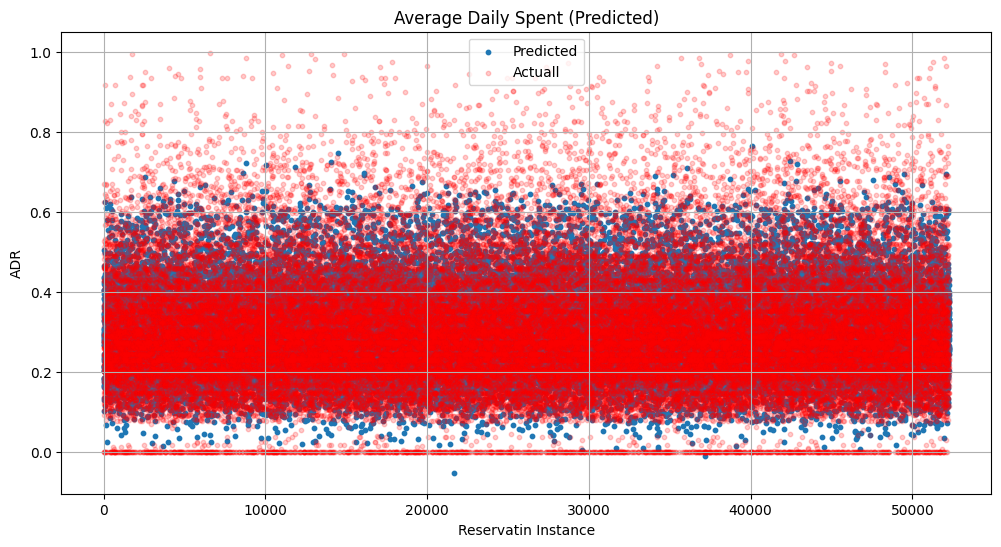

In [6]:
predicted_adr_train = model.predict(X_train)
predicted_adr_test = model.predict(X_test)
x = np.arange(0,len(predicted_adr_test),1)
plt.figure(figsize=(12,6))
plt.scatter(x,predicted_adr_test,s=10)
plt.scatter(x,y_test,alpha=.2,s=10,c="r")
plt.legend(["Predicted","Actuall"])
plt.grid()
plt.title("Average Daily Spent (Predicted)")
plt.ylabel("ADR")
plt.xlabel("Reservatin Instance")
plt.show()

### Measuring different error kinds
### Note that since there are zeros among our actuall data, we can not use MAPE as it will result in very high and misleading numbers.

In [7]:
print('RMSE on the train set is: %.2f' %pow(mean_squared_error(y_train,predicted_adr_train),.5))
print('RMSE on the test set is: %.2f' %pow(mean_squared_error(y_test,predicted_adr_test),0.5))
print('MAE on the train set is %.2f' %mean_absolute_error(y_train, predicted_adr_train))
print('MAE on the test set is %.2f' %mean_absolute_error(y_test, predicted_adr_test))
print('R2 Score is %.3f' %r2_score(y_test, predicted_adr_test))

RMSE on the train set is: 0.11
RMSE on the test set is: 0.12
MAE on the train set is 0.09
MAE on the test set is 0.09
R2 Score is 0.393


#### We see that all errors are relatively high even for train dataset. The reason is that the linear model can not predict zero inflated (many zeros among many positive values) data as it is shown in the plot. Not a single zero value has been predicted.
#### There are workarounds to this problem that still uses linear regression, but for the sake of practice we are going to use another model.

### Kernel Regression
#### Since the whole dataset is to large to apply kernel on, we use a subset of the data for our analysis

In [8]:
kdf = ndf[:10000]
kadr = kdf.pop("adr")
X_train_kernel, X_test_kernel, y_train_kernel, y_test_kernel = train_test_split(kdf,kadr,test_size=0.7)

model = KernelRidge(kernel="sigmoid")
model.fit(X_train_kernel, y_train_kernel)

predicted_adr_train = model.predict(X_train_kernel)
predicted_adr_test = model.predict(X_test_kernel)

print('RMSE on the train set is: %.2f' %pow(mean_squared_error(y_train_kernel,predicted_adr_train),.5))
print('RMSE on the test set is: %.2f' %pow(mean_squared_error(y_test_kernel,predicted_adr_test),0.5))
print('MAE on the train set is %.2f' %mean_absolute_error(y_train_kernel, predicted_adr_train))
print('MAE on the test set is %.2f' %mean_absolute_error(y_test_kernel, predicted_adr_test))
print('R2 Score is %.3f' %r2_score(y_test_kernel, predicted_adr_test))

RMSE on the train set is: 0.12
RMSE on the test set is: 0.12
MAE on the train set is 0.09
MAE on the test set is 0.09
R2 Score is 0.340


#### Through trial and error it is visible that sigmoid kernel results in the best scores, but still it is not very much better than linear model. Even increasing the size of the portion that the analysis is done on, results in convergance of all metrics.

### Ridge

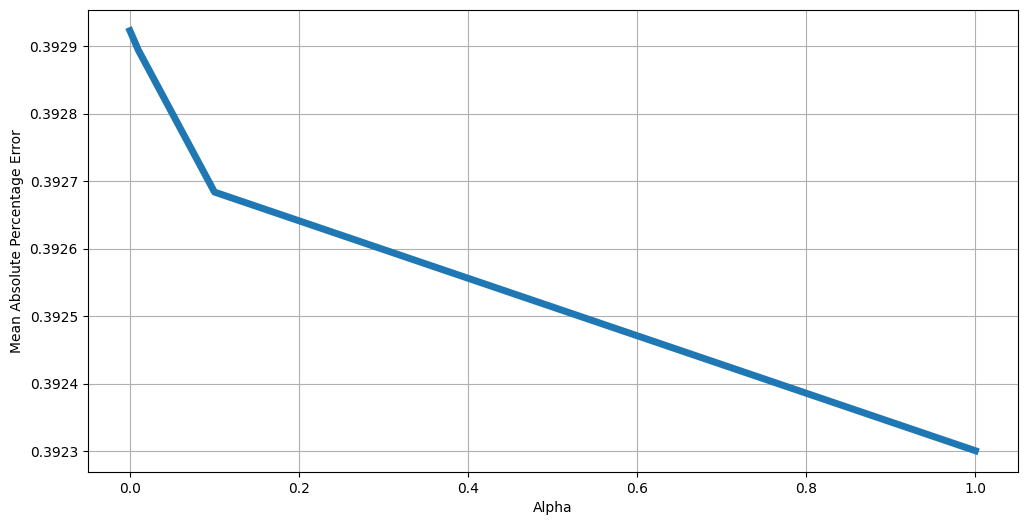

In [9]:
alpha_list = [0.000001,.0001,.0005,.001,.005,0.01,.1,1]
scores = []
for alpha in alpha_list:
  model = Ridge(alpha=alpha)
  model.fit(X_train, y_train)
  predicted_prices_test = model.predict(X_test)
  MAPE_test = r2_score(y_test, predicted_prices_test)
  scores.append(MAPE_test)
plt.figure(figsize=(12,6))
plt.plot(alpha_list,scores,lw=5)
plt.xlabel('Alpha')
plt.ylabel('Mean Absolute Percentage Error')
plt.grid()
plt.show()

#### Ridge regression is almost the same as linear in r2 metric.

### Lasso Regression

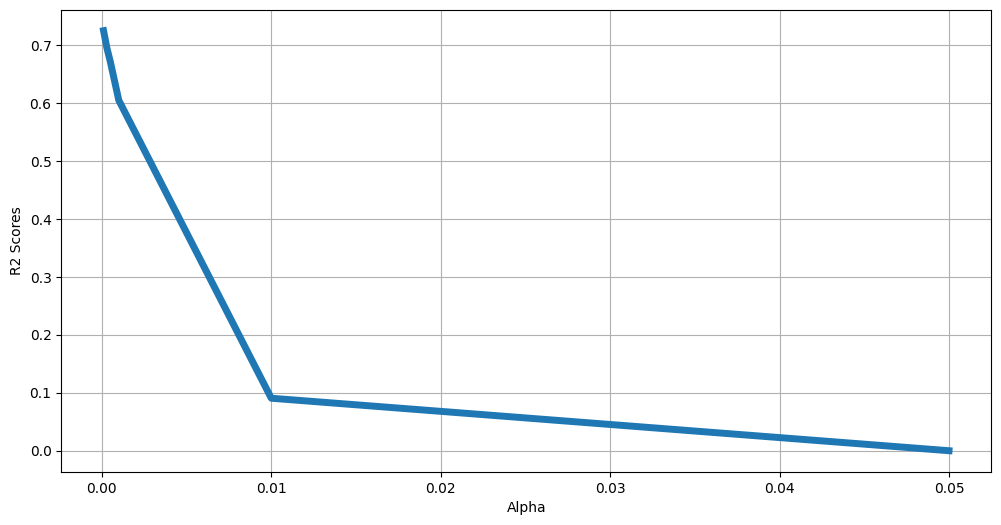

In [ ]:
pdf = ndf[:10000].copy(True)
padr = pdf.pop('adr')
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(pdf,padr,test_size=0.7)
poly = PolynomialFeatures(degree=2)
X_train_transformed_poly = poly.fit_transform(X_train_poly)
X_test_transformed_poly = poly.transform(X_test_poly)

scores = []
selector = SelectKBest(mutual_info_regression, k = 400)
selector.fit(X_train_transformed_poly, y_train_poly)
X_train_transformed = selector.transform(X_train_transformed_poly)
X_test_transform = selector.transform(X_test_transformed_poly)
alpha_list = [.0001,0.0003,0.0005,.001,0.01,0.05]
scores = []
for alpha in alpha_list:
    model = Lasso(alpha=alpha,)
    model.fit(X_train_transformed, y_train_poly)
    predicted_prices_test = model.predict(X_test_transform)
    r2 = r2_score(y_test_poly, predicted_prices_test)
    scores.append(r2)
plt.figure(figsize=(12,6))
plt.plot(alpha_list,scores,lw=5)
plt.xlabel('Alpha')
plt.ylabel('R2 Scores')
plt.grid()
plt.show()

#### Lasso regression results in a better R2 score than the other methods.

### Elastic Net

In [11]:
from sklearn.linear_model import ElasticNet

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

elastic_net = ElasticNet(alpha=.001, l1_ratio=.7, random_state=42)
elastic_net.fit(X_train_scaled, y_train)

y_pred_train = elastic_net.predict(X_train_scaled)
y_pred_test = elastic_net.predict(X_test_scaled)

print(f"R2: {r2_score(y_train, y_pred_train):.4f}")
print(f"R2: {r2_score(y_test, y_pred_test):.4f}")
print(f"MAE:{mean_absolute_error(y_test, y_pred_test):.2f}")

R2: 0.4005
R2: 0.3914
MAE:0.09


<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">Kernel Trick</b>: In cases that our features have non-linear relations we can not use linear algorithms on it to capture those relations. We could use non-linear models but those are usually computation heavy. Another option is to perform a non-linear operation on the features and gain new features that have linear relations and then use linear models on the new features. This is a nice trick to exploit beacuse it basically allows us to perform non-linear learning with the cost of linear methods.</p> 

<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">What Is The Best Model</b>: According to R2 metric, the best model (with some tuning) is the Lasso regressor. The main reason that other models failed to perorm well but lasso didn't is that we transformed the data and intorudeced non-linear features which is essential for capturing non-linear relations using linear models. This shows that the realtion between the features and the target column is mainly non-linear.</p>

<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">What Is The Best Metric</b>: Given that outliers is not of significant importance and not the center of our focus a metric that is resistance to extreme values is preferable like mean aboslute error (MSE).</p>

<b style="display: block;font-size: 2.1rem;">When to use each model:</b>
<div style="font-size: 1.8rem;margin-left: .5rem;">
    <p style="margin-left: .8rem;">Linear</p>
    <ul style="margin-left: 1.6rem;">
        <li>Linear Relations</li>
        <li>Independent Features</li>
        <li>Few Features</li>
    </ul>
    <p style="margin-left: .8rem;">Kernel Regression</p>
    <ul style="margin-left: 1.6rem;">
        <li>Strong Non-Linear Patterns</li>
        <li>Relatively Small Dataset</li>
        <li>Smooth Relations (No Sharp Changes)</li>
    </ul>
    <p style="margin-left: .8rem;">Ridge Regression</p>
    <ul style="margin-left: 1.6rem;">
        <li>Many Features</li>
        <li>All Features Are Useful</li>
        <li>Correlated Features</li>
    </ul>
    <p style="margin-left: .8rem;">Lasso Regression</p>
    <ul style="margin-left: 1.6rem;">
        <li>Many Irrelevant Features</li>
        <li>Heavy Polynomial Relations</li>
        <li>Few Features Actually Matter</li>
    </ul>
</div>

## Binary Classification Methods
#### We try to use binary classification to determine the status of the reservation as a binary classifier (i.e. canceled or not). Later we use multi class classification (i.e. canceled, checked out or no show) and compare the two approach.

### Logistic Regression

In [ ]:
lgr_df = odf.copy(True)
canceles = lgr_df.pop("Canceled")
no_show = lgr_df.pop("No-Show")
check_out = lgr_df.pop("Check-Out")
X_train, X_test, y_train, y_test = train_test_split(lgr_df,canceles,test_size=0.7)

model = LogisticRegression(penalty='l1',solver="liblinear",max_iter=1000)
model.fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)

errors_train = (predictions_train != y_train).sum()
errors_test = (predictions_test != y_test).sum()

print("="*50)
print("TRAINING SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_train, predictions_train):.4f}")
print(f"Precision: {precision_score(y_train, predictions_train):.4f}")
print(f"Recall: {recall_score(y_train, predictions_train):.4f}")
print(f"F1-Score: {f1_score(y_train, predictions_train):.4f}")
print(f"AUC: {roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, predictions_train))

print("\n" + "="*50)
print("TEST SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, predictions_test):.4f}")
print(f"Precision: {precision_score(y_test, predictions_test):.4f}")
print(f"Recall: {recall_score(y_test, predictions_test):.4f}")
print(f"F1-Score: {f1_score(y_test, predictions_test):.4f}")
print(f"AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions_test))

TRAINING SET METRICS
Accuracy: 0.9338
Precision: 0.8876
Recall: 0.9357
F1-Score: 0.9110
AUC: 0.9774

Confusion Matrix:
[[21224  1530]
 [  830 12085]]

TEST SET METRICS
Accuracy: 0.9343
Precision: 0.8873
Recall: 0.9369
F1-Score: 0.9114
AUC: 0.9767

Confusion Matrix:
[[49619  3575]
 [ 1895 28140]]


### Support Vector Machine

In [ ]:
svmdf = odf.copy(True)

canceles = svmdf.pop("Canceled")
no_show = svmdf.pop("No-Show")
check_out = svmdf.pop("Check-Out")

X_train, X_test, y_train, y_test = train_test_split(svmdf, canceles, test_size=0.3)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(
    C=3,
    kernel='linear',
    gamma='scale',
    class_weight='balanced',
    probability=True,
    max_iter=5000,
)

model.fit(X_train, y_train)

t = 0.45
probs_train = model.predict_proba(X_train)[:, 1]
predictions_train = (probs_train > t).astype(int)
probs_test = model.predict_proba(X_test)[:, 1]
predictions_test = (probs_test > t).astype(int)

print("="*50)
print("TRAINING SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_train, predictions_train):.4f}")
print(f"Precision: {precision_score(y_train, predictions_train):.4f}")
print(f"Recall: {recall_score(y_train, predictions_train):.4f}")
print(f"F1-Score: {f1_score(y_train, predictions_train):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, predictions_train))

print("\n" + "="*50)
print("TEST SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, predictions_test):.4f}")
print(f"Precision: {precision_score(y_test, predictions_test):.4f}")
print(f"Recall: {recall_score(y_test, predictions_test):.4f}")
print(f"F1-Score: {f1_score(y_test, predictions_test):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions_test))

weights_linear = model.coef_[0]
fig, ax = plt.subplots(figsize=(20,8))
y_pos = np.arange(0,len(weights_linear),1)
labels = list(svmdf.columns)
hbars = ax.barh(y_pos, weights_linear, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Weights')
ax.set_title("Importance of each column from the algorithm's point of view")
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


TRAINING SET METRICS
Accuracy: 0.8972
Precision: 0.8697
Recall: 0.8420
F1-Score: 0.8557

Confusion Matrix:
[[49313  3798]
 [ 4758 25359]]

TEST SET METRICS
Accuracy: 0.8958
Precision: 0.8633
Recall: 0.8440
F1-Score: 0.8535

Confusion Matrix:
[[21122  1715]
 [ 2002 10831]]


### Kernel SVM

In [ ]:
lgrdf = odf.copy(True)

canceles = lgrdf.pop("Canceled")
no_show = lgrdf.pop("No-Show")
check_out = lgrdf.pop("Check-Out")

X_train, X_test, y_train, y_test = train_test_split(lgrdf, canceles, test_size=0.3)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(
    C=3,
    kernel='rbf',
    gamma='scale',
    class_weight='balanced',
    probability=True,
    max_iter=5000,
)

model.fit(X_train, y_train)

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    probs_train = model.predict_proba(X_train)[:, 1]
    predictions_train = (probs_train > t).astype(int)

    probs_test = model.predict_proba(X_test)[:, 1]
    predictions_test = (probs_test > t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_train, predictions_train).ravel()
    print(f"Train Threshold={t} | FP={fp}, FN={fn}")

    tn, fp, fn, tp = confusion_matrix(y_test, predictions_test).ravel()
    print(f"Test Threshold={t} | FP={fp}, FN={fn}")

print("="*50)
print("TRAINING SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_train, predictions_train):.4f}")
print(f"Precision: {precision_score(y_train, predictions_train):.4f}")
print(f"Recall: {recall_score(y_train, predictions_train):.4f}")
print(f"F1-Score: {f1_score(y_train, predictions_train):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, predictions_train))

print("\n" + "="*50)
print("TEST SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, predictions_test):.4f}")
print(f"Precision: {precision_score(y_test, predictions_test):.4f}")
print(f"Recall: {recall_score(y_test, predictions_test):.4f}")
print(f"F1-Score: {f1_score(y_test, predictions_test):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions_test))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Train Threshold=0.3 | FP=1568, FN=219
Test Threshold=0.3 | FP=748, FN=220
Train Threshold=0.4 | FP=1407, FN=272
Test Threshold=0.4 | FP=650, FN=266
Train Threshold=0.5 | FP=1232, FN=369
Test Threshold=0.5 | FP=564, FN=353
Train Threshold=0.6 | FP=1076, FN=529
Test Threshold=0.6 | FP=483, FN=447
Train Threshold=0.7 | FP=904, FN=904
Test Threshold=0.7 | FP=408, FN=612
TRAINING SET METRICS
Accuracy: 0.9783
Precision: 0.9699
Recall: 0.9699
F1-Score: 0.9699

Confusion Matrix:
[[52312   904]
 [  904 29108]]

TEST SET METRICS
Accuracy: 0.9714
Precision: 0.9680
Recall: 0.9527
F1-Score: 0.9603

Confusion Matrix:
[[22324   408]
 [  612 12326]]


#### Kernel SVM resulted in pretty good metrics but it is orders of magnitude slower and computationally heavier than other methods so it is not really preferable.

### KNN

TRAINING SET METRICS
Accuracy: 0.8907
Precision: 0.9122
Recall: 0.7707
F1-Score: 0.8355

Confusion Matrix:
[[51039  2223]
 [ 6872 23094]]

TEST SET METRICS
Accuracy: 0.8497
Precision: 0.8519
Recall: 0.7106
F1-Score: 0.7749

Confusion Matrix:
[[21082  1604]
 [ 3757  9227]]


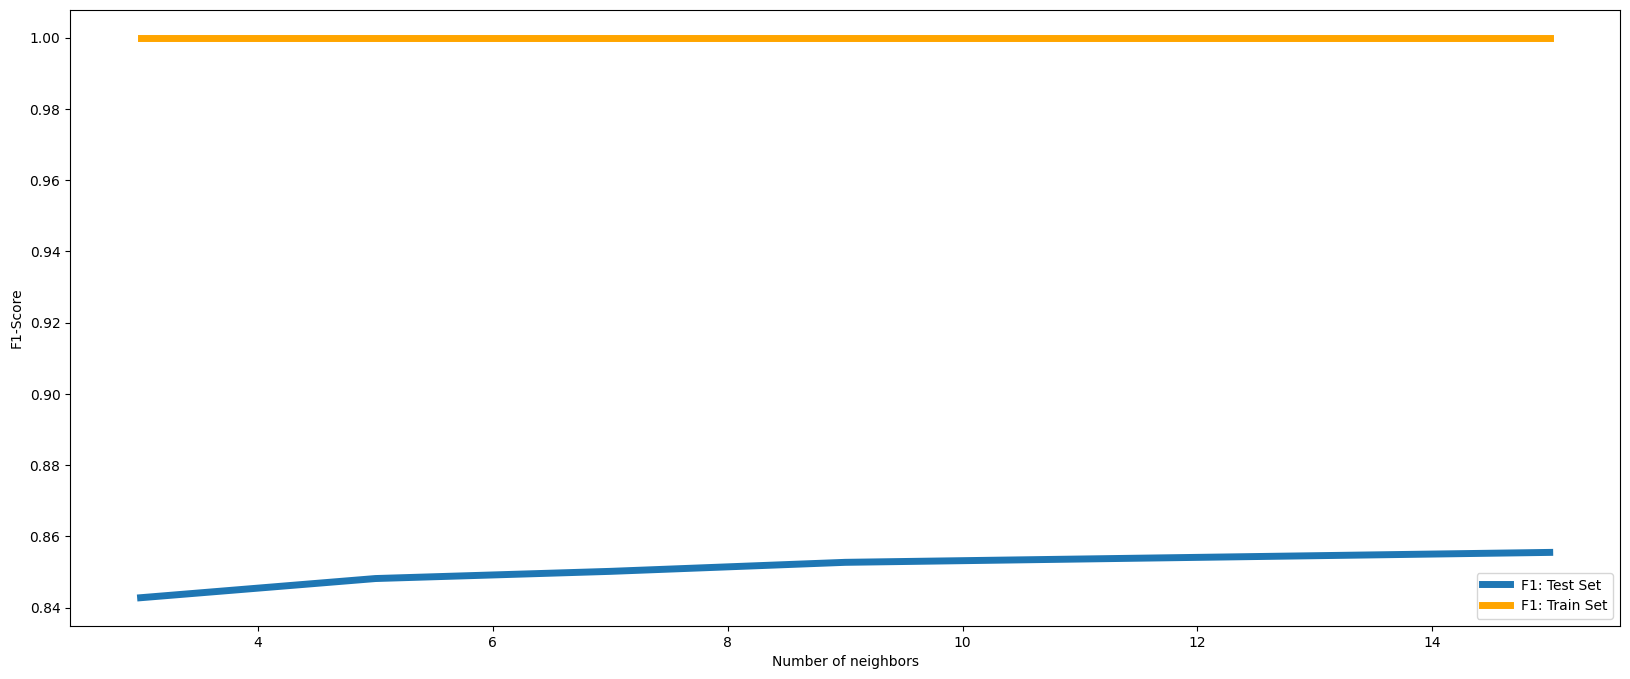

In [12]:
knndf = odf.copy(True)

canceles = knndf.pop("Canceled")
no_show = knndf.pop("No-Show")
check_out = knndf.pop("Check-Out")

X_train, X_test, y_train, y_test = train_test_split(knndf, canceles, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define model first
model = KNeighborsClassifier(n_neighbors=6, weights='uniform')
model.fit(X_train, y_train)

predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)

print("="*50)
print("TRAINING SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_train, predictions_train):.4f}")
print(f"Precision: {precision_score(y_train, predictions_train):.4f}")
print(f"Recall: {recall_score(y_train, predictions_train):.4f}")
print(f"F1-Score: {f1_score(y_train, predictions_train):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, predictions_train))

print("\n" + "="*50)
print("TEST SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, predictions_test):.4f}")
print(f"Precision: {precision_score(y_test, predictions_test):.4f}")
print(f"Recall: {recall_score(y_test, predictions_test):.4f}")
print(f"F1-Score: {f1_score(y_test, predictions_test):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions_test))

# Tuning neighbors
neighbors_list = [3, 5, 7, 9, 15]
scores = []
scores_train = []
for n in neighbors_list:
    model = KNeighborsClassifier(n_neighbors=n, weights='distance')
    model.fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    F1_train = f1_score(y_train, predictions_train, average='macro')
    scores_train.append(F1_train)
    predictions = model.predict(X_test)
    F1 = f1_score(y_test, predictions, average='macro')
    scores.append(F1)
plt.figure(figsize=(20, 8))
plt.plot(neighbors_list, scores, lw=5)
plt.plot(neighbors_list, scores_train, lw=5, color='orange')
plt.xlabel('Number of neighbors')
plt.ylabel('F1-Score')
plt.legend(['F1: Test Set', 'F1: Train Set'])
plt.show()

### Decision Tree

In [46]:
def extract_feature_importance(decision_model,labels,decision_model_name='dt'):

  '''
  This function visualizes the important parameters
  '''

  labels_range = range(0,len(labels))
  if  decision_model_name == 'dt':
    trees = [decision_model]
  else:
    trees = decision_model.estimators_

  cnt = 1
  feature_importances = np.zeros([len(trees),len(labels)])
  itr = 0
  for item in trees:
    feature_importances[itr,:] = item.feature_importances_
    itr += 1

  feature_importances_mean = feature_importances.mean(axis=0)
  feature_importances_std = feature_importances.std(axis=0)

  return feature_importances_mean

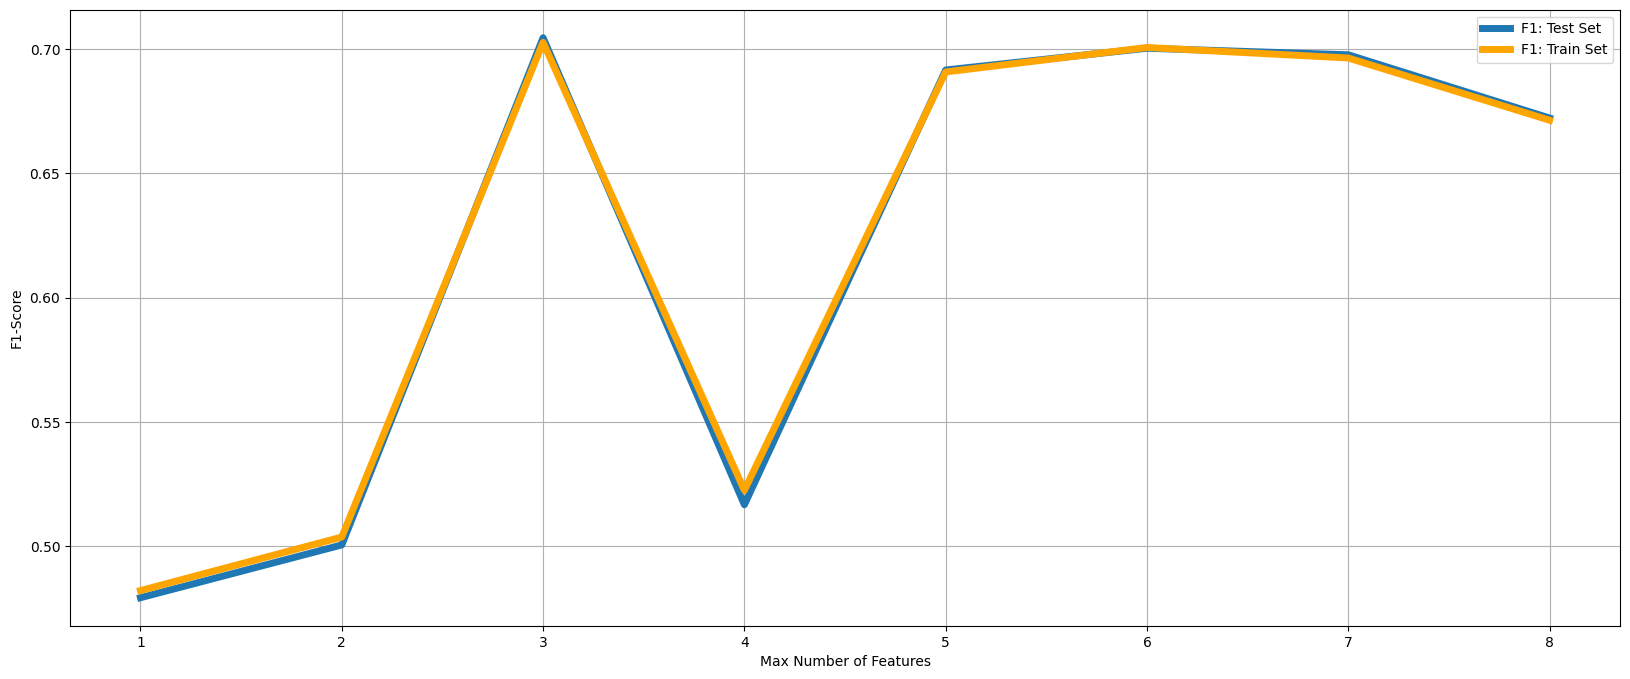

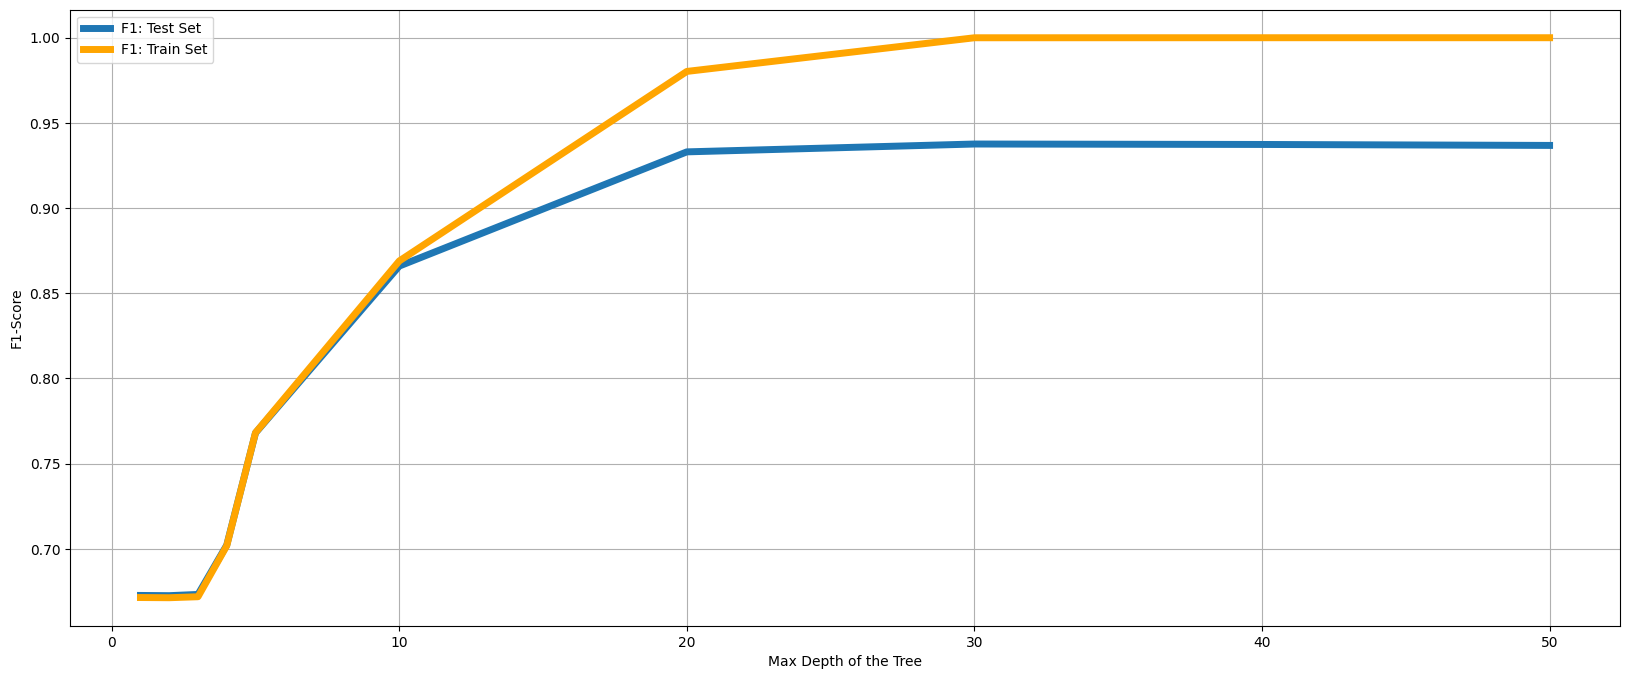

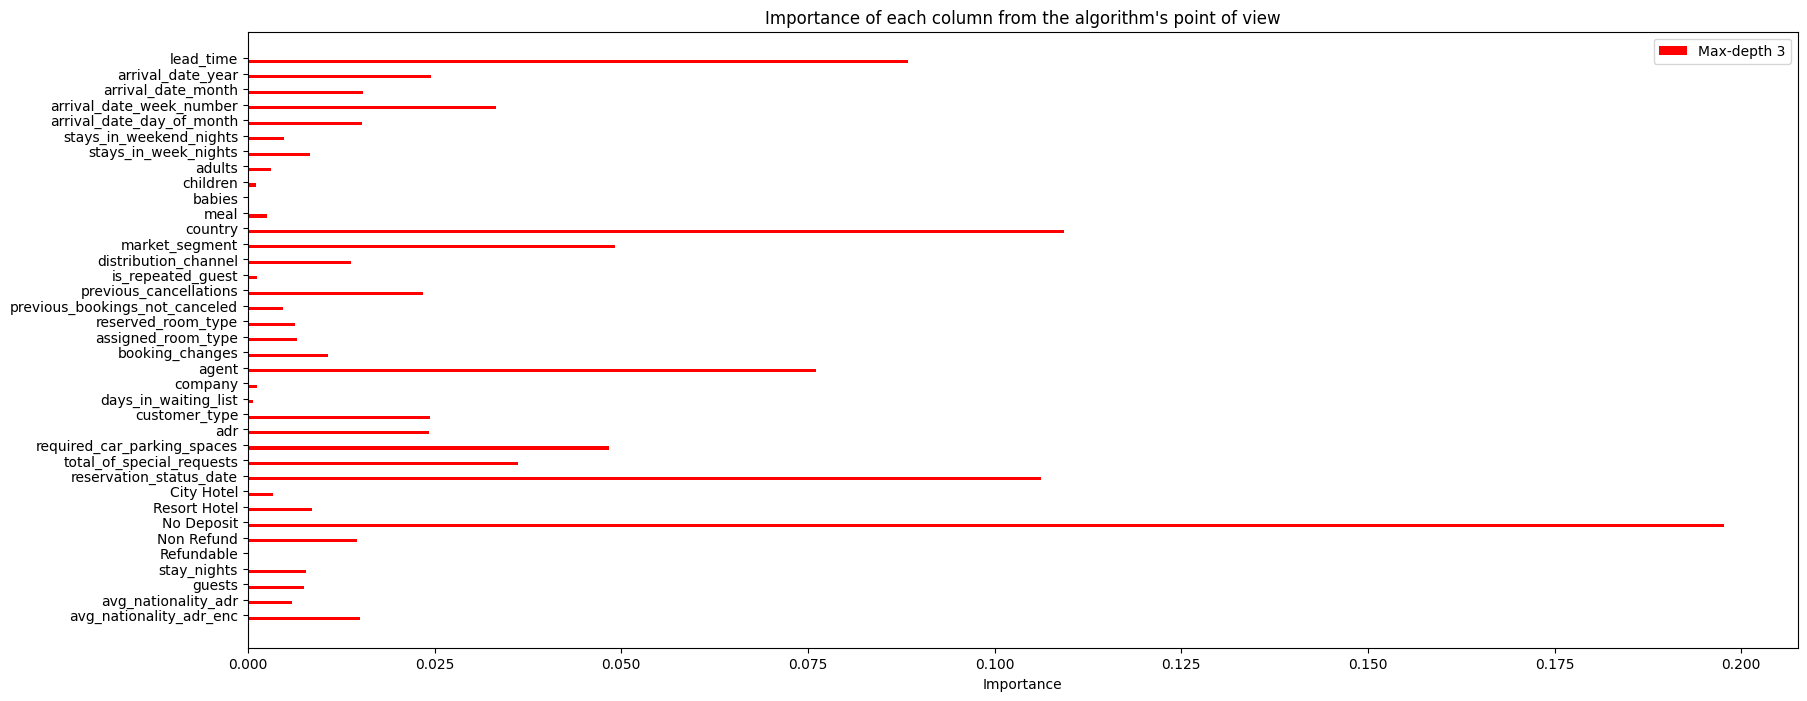

TRAINING SET METRICS
Accuracy: 0.9057
Precision: 0.8885
Recall: 0.8449
F1-Score: 0.8662
AUC: 0.9746

Confusion Matrix:
[[49969  3187]
 [ 4665 25407]]

TEST SET METRICS
Accuracy: 0.8763
Precision: 0.8430
Recall: 0.8077
F1-Score: 0.8250
AUC: 0.9375

Confusion Matrix:
[[20855  1937]
 [ 2476 10402]]


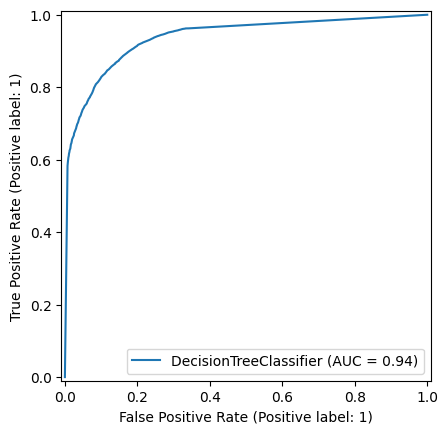

In [69]:
# Prepering data
kkndf = odf.copy(True)
canceles = kkndf.pop("Canceled")
no_show = kkndf.pop("No-Show")
check_out = kkndf.pop("Check-Out")
X_train, X_test, y_train, y_test = train_test_split(kkndf, canceles, test_size=0.3)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Searching for optimum number of features
scores = []
features_list = [1,2,3,4,5,6,7,8]
scores = []
scores_train = []

for no_features in features_list:
    model = DecisionTreeClassifier(max_features=no_features,max_depth=3)
    model.fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    F1_train = f1_score(y_train, predictions_train, average='macro')
    scores_train.append(F1_train)

    predictions = model.predict(X_test)
    F1 = f1_score(y_test, predictions, average='macro')
    scores.append(F1)

plt.figure(figsize=(20,8))
plt.plot(features_list,scores,lw=5)
plt.plot(features_list,scores_train,lw=5,color='orange')
plt.xlabel('Max Number of Features')
plt.ylabel('F1-Score')
plt.legend(['F1: Test Set','F1: Train Set'])
plt.grid()
plt.show()

# Searching for optimum maximum depth
scores = []
depths_list = [1,2,3,4,5,10,20,30,40,50]
scores = []
scores_train = []
for depth in depths_list:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    F1_train = f1_score(y_train, predictions_train, average='macro')
    scores_train.append(F1_train)

    predictions = model.predict(X_test)
    F1 = f1_score(y_test, predictions, average='macro')
    scores.append(F1)

plt.figure(figsize=(20,8))
plt.plot(depths_list,scores,lw=5)
plt.plot(depths_list,scores_train,lw=5,color='orange')
plt.xlabel('Max Depth of the Tree')
plt.ylabel('F1-Score')
plt.legend(['F1: Test Set','F1: Train Set'])
plt.grid()
plt.show()

# Final model
model = DecisionTreeClassifier(criterion='entropy',max_features=6,max_depth=20,min_samples_leaf=5)
model.fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)

# Visualizing features importance's
labels = list(knndf.columns)
features_importance = extract_feature_importance(model,labels,decision_model_name='dt')
fig, ax = plt.subplots(figsize=(20,8))
y_pos = np.arange(0,len(features_importance),1)
hbars = ax.barh(y_pos+0.2, features_importance, align='center',color='red',height=0.2)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title("Importance of each column from the algorithm's point of view")
plt.legend(['Max-depth 3','Max-depth 10'])
plt.show()

# Plotting ROC curve
RocCurveDisplay.from_estimator(model, X_test, y_test)

# Metrics for train data
print("="*50)
print("TRAINING SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_train, predictions_train):.4f}")
print(f"Precision: {precision_score(y_train, predictions_train):.4f}")
print(f"Recall: {recall_score(y_train, predictions_train):.4f}")
print(f"F1-Score: {f1_score(y_train, predictions_train):.4f}")
print(f"AUC: {roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, predictions_train))

# Metrics for test data
print("\n" + "="*50)
print("TEST SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, predictions_test):.4f}")
print(f"Precision: {precision_score(y_test, predictions_test):.4f}")
print(f"Recall: {recall_score(y_test, predictions_test):.4f}")
print(f"F1-Score: {f1_score(y_test, predictions_test):.4f}")
print(f"AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions_test))


#### We could plot the tree and its leaves but the depth is too large and the number of leaves are too high that the tree chart does not contain any meaningful info.

### Random Forest

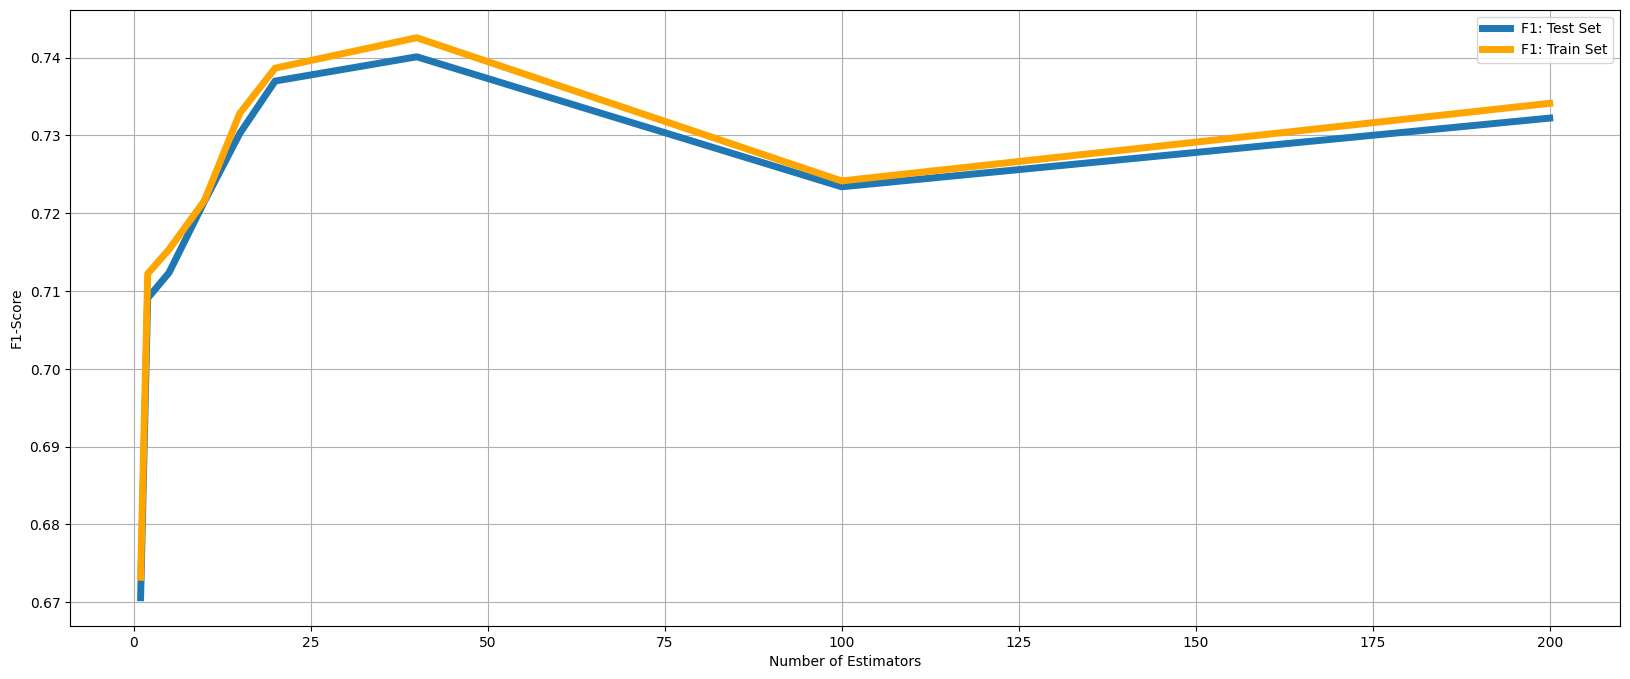

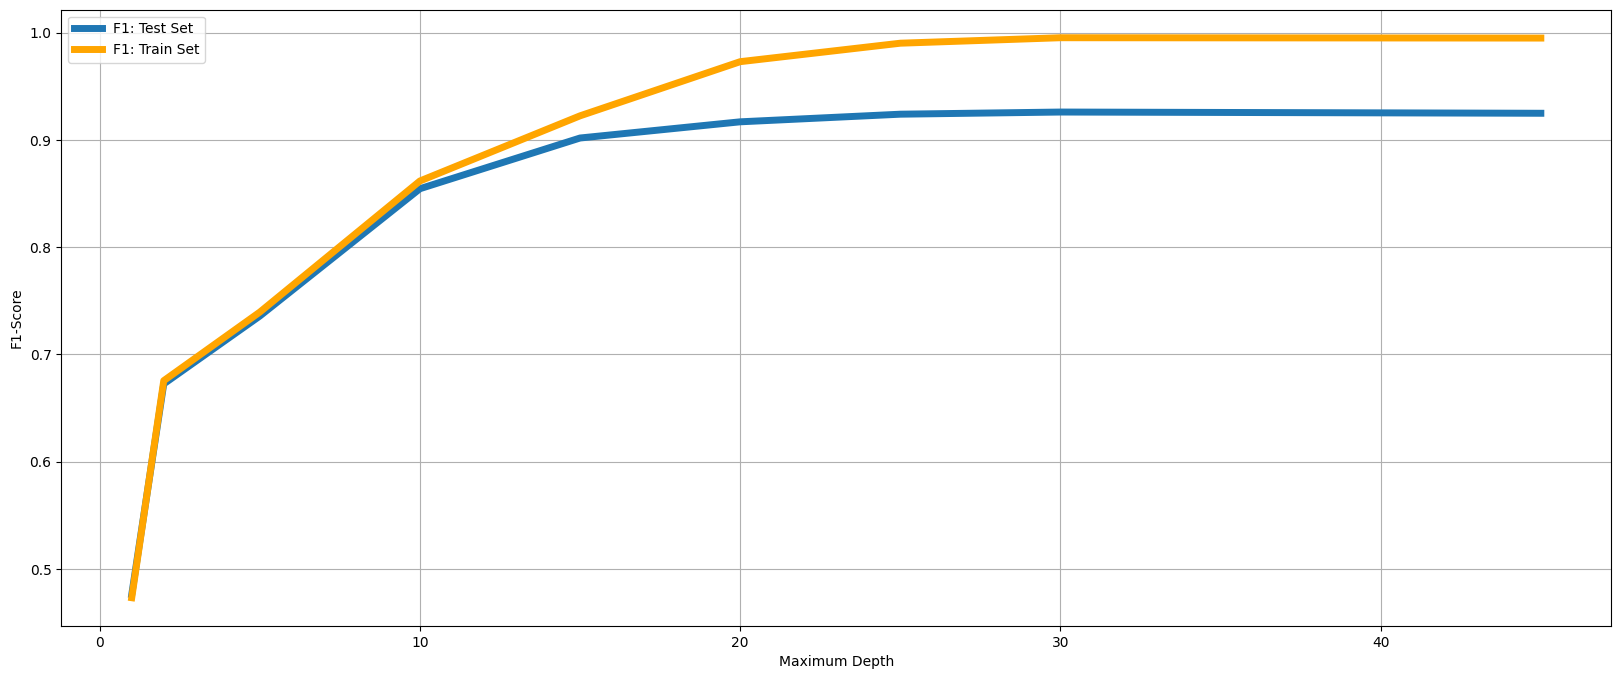

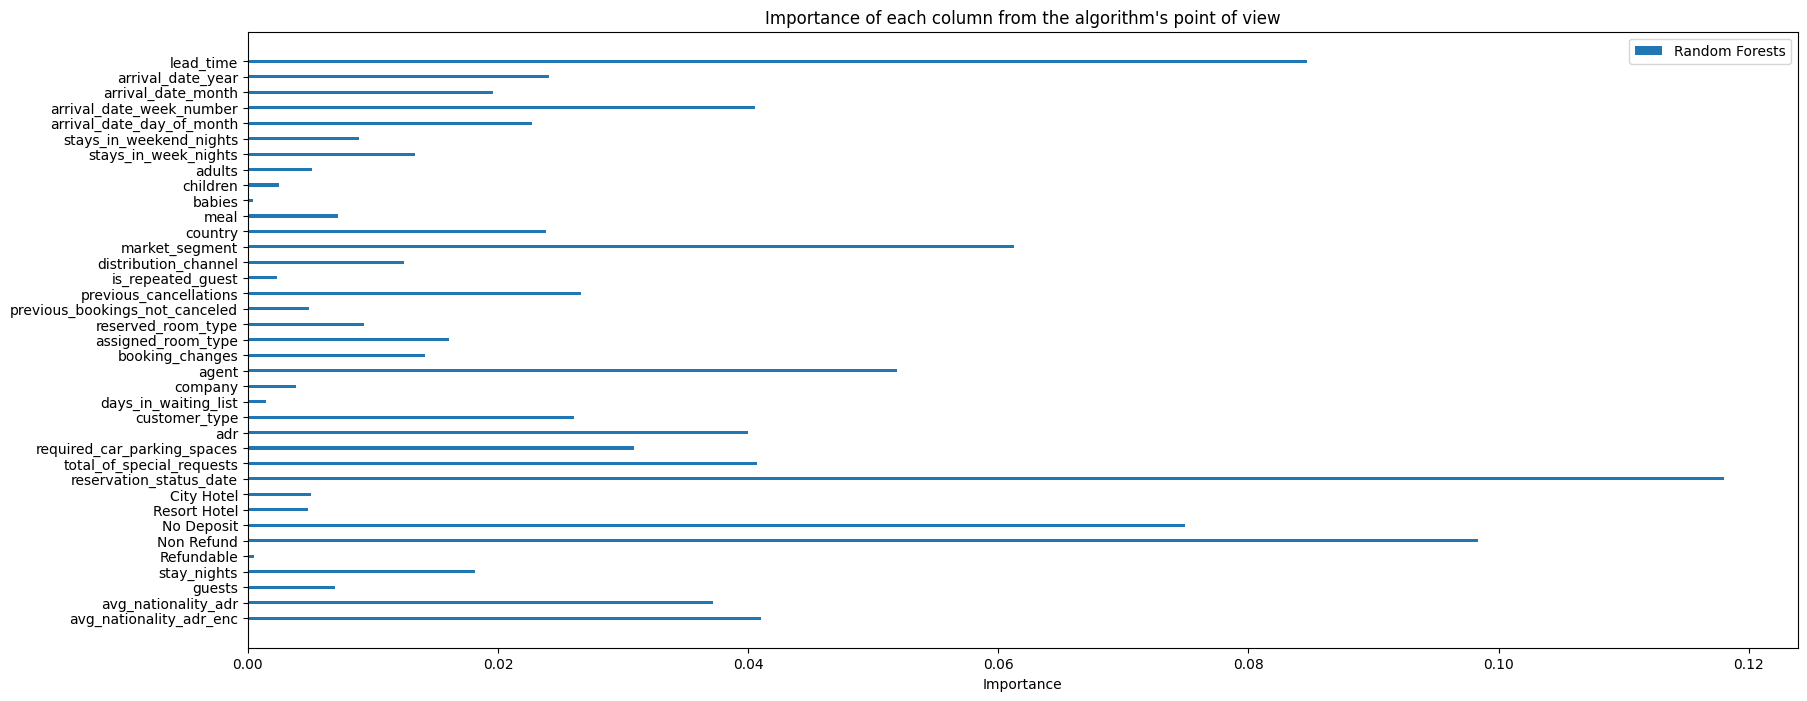

TRAINING SET METRICS
Accuracy: 0.9715
Precision: 0.9737
Recall: 0.9469
F1-Score: 0.9601
AUC: 0.9976

Confusion Matrix:
[[52310   772]
 [ 1601 28545]]

TEST SET METRICS
Accuracy: 0.9298
Precision: 0.9335
Recall: 0.8661
F1-Score: 0.8986
AUC: 0.9793

Confusion Matrix:
[[22076   790]
 [ 1714 11090]]


In [ ]:
# Prepring data
rfdf = odf.copy(True)
canceles = rfdf.pop("Canceled")
no_show = rfdf.pop("No-Show")
check_out = rfdf.pop("Check-Out")
X_train, X_test, y_train, y_test = train_test_split(rfdf, canceles, test_size=0.3)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Searching for optimum n_estimators
scores = []
no_estimators = [1,2,5,10,15,20,40,100,200]
scores = []
scores_train = []
for no_estimator in no_estimators:
    model = RandomForestClassifier(n_estimators=no_estimator,max_depth=5)
    model.fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    F1_train = f1_score(y_train, predictions_train, average='macro')
    scores_train.append(F1_train)

    predictions = model.predict(X_test)
    F1 = f1_score(y_test, predictions, average='macro')
    scores.append(F1)

plt.figure(figsize=(20,8))
plt.plot(no_estimators,scores,lw=5)
plt.plot(no_estimators,scores_train,lw=5,color='orange')
plt.xlabel('Number of Estimators')
plt.ylabel('F1-Score')
plt.legend(['F1: Test Set','F1: Train Set'])
plt.grid()
plt.show()

# Searching for optimum max depth
max_depths = [1,2,5,10,15,20,25,30,45]
scores = []
scores_train = []
for md in max_depths:
    model = RandomForestClassifier(n_estimators=10,max_depth=md)
    model.fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    F1_train = f1_score(y_train, predictions_train, average='macro')
    scores_train.append(F1_train)
    predictions = model.predict(X_test)
    F1 = f1_score(y_test, predictions, average='macro')
    scores.append(F1)

plt.figure(figsize=(20,8))
plt.plot(max_depths,scores,lw=5)
plt.plot(max_depths,scores_train,lw=5,color='orange')
plt.xlabel('Maximum Depth')
plt.ylabel('F1-Score')
plt.legend(['F1: Test Set','F1: Train Set'])
plt.grid()
plt.show()

# Final model
model = RandomForestClassifier(n_estimators=100,criterion='entropy',max_depth=20)
model.fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)

# Visualizing feature importance
labels = list(rfdf.columns)
features_importance_rf = extract_feature_importance(model,labels,decision_model_name='rf')
fig, ax = plt.subplots(figsize=(20,8))
y_pos = np.arange(0,len(features_importance_rf),1)
hbars = ax.barh(y_pos, features_importance_rf, align='center',height=.2)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title("Importance of each column from the algorithm's point of view")
plt.legend(['Random Forests','Decision Tree'])
plt.show()

# Metrics for train data
print("="*50)
print("TRAINING SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_train, predictions_train):.4f}")
print(f"Precision: {precision_score(y_train, predictions_train):.4f}")
print(f"Recall: {recall_score(y_train, predictions_train):.4f}")
print(f"F1-Score: {f1_score(y_train, predictions_train):.4f}")
print(f"AUC: {roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, predictions_train))

#Metrics for test data 
print("\n" + "="*50)
print("TEST SET METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, predictions_test):.4f}")
print(f"Precision: {precision_score(y_test, predictions_test):.4f}")
print(f"Recall: {recall_score(y_test, predictions_test):.4f}")
print(f"F1-Score: {f1_score(y_test, predictions_test):.4f}")
print(f"AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions_test))

<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">What Is The Best Model</b>: The difference is not significant but random forest performs relatively better. This means that the relation between the features is not evenly ditributed, some are more related and some less.</p>

<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">What Is The Best Metric</b>: F1-score works the best as a general metric since it includes both percision and recall. It also handles class imbalance better.</p>

<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">Decision Tree Regularization</b>: To regularize decision tree algorithm we can <b style="text-decoration: underline;">limit max depth</b> and prevent overfitting. Another method we can use is to use <b style="text-decoration: underline;">minimum leaf sample</b> which prevents the leaves from breaking down into too specific catgories that only includes a few samples and decreases the chance of overfitting.<b style="text-decoration: underline;">Limiting max features</b> is yet another method we can use to reduce specificity and increases regularization at each node.</p>

<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">SVM vs Kernel SVM</b>: SVM tries to find lines or planes that separate the data which is at disatvantage when the relation among the data is non-linear. Kernel SVM however uses the kernel trick that we explained earlier to map the data into a higher dimension and create linear relations which linear SVM can work on just fine.</p>

### Multi Class Classification

In [14]:
def multi_class_metrics(data,y_true, y_pred, class_names=None, y_proba=None):
    """
    Calculate multi-class classification metrics for each class
    
    Parameters:
    y_true: actual labels
    y_pred: predicted labels  
    class_names: list of class names (optional)
    """
    
    # Get unique classes
    classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(classes)
    
    if class_names is None:
        class_names = [f"Class_{c}" for c in classes]
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Initialize storage
    precision_per_class = []
    recall_per_class = []
    f1_per_class = []
    
    # Calculate metrics for each class (One-vs-All approach)
    for i, class_label in enumerate(classes):
        # True Positives: correctly predicted as this class
        tp = cm[i, i]
        
        # False Positives: predicted as this class but actual is other
        fp = cm[:, i].sum() - tp
        
        # False Negatives: actual is this class but predicted as other
        fn = cm[i, :].sum() - tp
        
        # True Negatives: actual and predicted are other classes
        tn = cm.sum() - tp - fp - fn
        
        # Calculate metrics for this class
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precision_per_class.append(precision)
        recall_per_class.append(recall)
        f1_per_class.append(f1)
    
    # Calculate macro, micro, weighted averages
    macro_precision = np.mean(precision_per_class)
    macro_recall = np.mean(recall_per_class)
    macro_f1 = np.mean(f1_per_class)
    
    # Micro: aggregate totals first
    total_tp = sum([cm[i, i] for i in range(n_classes)])
    total_fp = sum([cm[:, i].sum() - cm[i, i] for i in range(n_classes)])
    total_fn = sum([cm[i, :].sum() - cm[i, i] for i in range(n_classes)])
    
    micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    micro_f1 = 2 * (micro_precision * micro_recall) / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0
    
    # Weighted: weighted by support (number of true instances per class)
    support = [cm[i, :].sum() for i in range(n_classes)]
    total_samples = sum(support)
    
    weighted_precision = sum([p * s for p, s in zip(precision_per_class, support)]) / total_samples
    weighted_recall = sum([r * s for r, s in zip(recall_per_class, support)]) / total_samples
    weighted_f1 = sum([f * s for f, s in zip(f1_per_class, support)]) / total_samples
    
    kappa = cohen_kappa_score(y_true, y_pred)

    # Create results DataFrame
    results_df = pd.DataFrame({
        'Class': class_names,
        'Precision': precision_per_class,
        'Recall': recall_per_class,
        'F1-Score': f1_per_class,
        'Support': support
    })
    
    # Display results
    print("="*70)
    print(f"MULTI-CLASS CLASSIFICATION METRICS ({data})")
    print("="*70)
    print(results_df.to_string(index=False, float_format='%.4f'))
    
    print("\n" + "="*70)
    print(f"AGGREGATED METRICS ({data})")
    print("="*70)
    print(f"\nAccuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"\nMacro Average:")
    print(f"  Precision: {macro_precision:.4f}")
    print(f"  Recall:    {macro_recall:.4f}")
    print(f"  F1-Score:  {macro_f1:.4f}")
    print(f"\nMicro Average:")
    print(f"  Precision: {micro_precision:.4f}")
    print(f"  Recall:    {micro_recall:.4f}")
    print(f"  F1-Score:  {micro_f1:.4f}")
    print(f"\nWeighted Average:")
    print(f"  Precision: {weighted_precision:.4f}")
    print(f"  Recall:    {weighted_recall:.4f}")
    print(f"  F1-Score:  {weighted_f1:.4f}")
    print(f"\nOverall Kappa: {kappa:.4f}")  # ONE number
    
    if y_proba is not None:
        ll = log_loss(y_true,y_proba)
        print(f"\nLog Loss: {ll:.4f}")

    # Confusion matrix shows per-class performance
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)    
    return

In [15]:
mcdf = odf.copy(True)
numerizing_kernel = {'Canceled': 0, 'No-Show': 1, 'Check-Out': 2}
target = mcdf[list(numerizing_kernel.keys())].dot(list(numerizing_kernel.values()))
canceles = mcdf.pop("Canceled")
no_shows = mcdf.pop("No-Show")
check_out = mcdf.pop("Check-Out")

X_train, X_test, y_train, y_test = train_test_split(mcdf, target, test_size=0.3)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)


### SVM Linear Kernel

In [57]:
model = SVC(C=3,kernel='linear',decision_function_shape = "ovr",max_iter=5000,class_weight={0: 1, 1: 28, 2: 1})
model.fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)

multi_class_metrics('Trainning',y_train,predictions_train,class_names=numerizing_kernel.keys())
multi_class_metrics('Testing',y_test,predictions_test,class_names=numerizing_kernel.keys())

/Users/parsajoneydi/.pyenv/versions/scientific/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


MULTI-CLASS CLASSIFICATION METRICS (Trainning)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.6029  0.8445    0.7036    30151
  No-Show     0.0128  0.1163    0.0230      808
Check-Out     0.8958  0.5764    0.7014    52269

AGGREGATED METRICS (Trainning)

Accuracy: 0.6691

Macro Average:
  Precision: 0.5038
  Recall:    0.5124
  F1-Score:  0.4760

Micro Average:
  Precision: 0.6691
  Recall:    0.6691
  F1-Score:  0.6691

Weighted Average:
  Precision: 0.7811
  Recall:    0.6691
  F1-Score:  0.6956

Overall Kappa: 0.4106

Confusion Matrix:
[[25464  1652  3035]
 [  243    94   471]
 [16528  5614 30127]]
MULTI-CLASS CLASSIFICATION METRICS (Testing)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.5992  0.8458    0.7014    12799
  No-Show     0.0144  0.1190    0.0257      395
Check-Out     0.8978  0.5727    0.6994    22476

AGGREGATED METRICS (Testing)

Accuracy: 0.6657

Macro Average:
  Precision: 0.5038
  Recall:    0.5125
  F1-Score:  0.4755

Micro Averag

### SVM RBF Kernel

In [ ]:
model = SVC(C=2,kernel='rbf',decision_function_shape = "ovo",max_iter=5000,class_weight={0: 1, 1: 28, 2: 1})
model.fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)

multi_class_metrics('Trainning',y_train,predictions_train,class_names=numerizing_kernel.keys())
multi_class_metrics('Testing',y_test,predictions_test,class_names=numerizing_kernel.keys())

/Users/parsajoneydi/.pyenv/versions/scientific/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


MULTI-CLASS CLASSIFICATION METRICS (Trainning)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9907  0.5183    0.6806    52181
  No-Show     0.9529  0.4448    0.6065    52181
Check-Out     0.4903  0.9856    0.6549    52181

AGGREGATED METRICS (Trainning)

Accuracy: 0.6496

Macro Average:
  Precision: 0.8113
  Recall:    0.6496
  F1-Score:  0.6473

Micro Average:
  Precision: 0.6496
  Recall:    0.6496
  F1-Score:  0.6496

Weighted Average:
  Precision: 0.8113
  Recall:    0.6496
  F1-Score:  0.6473

Overall Kappa: 0.4744

Confusion Matrix:
[[27047   525 24609]
 [  124 23208 28849]
 [  129   621 51431]]
MULTI-CLASS CLASSIFICATION METRICS (Testing)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9485  0.5103    0.6636    22564
  No-Show     0.8971  0.2161    0.3482    22564
Check-Out     0.4426  0.9832    0.6104    22564

AGGREGATED METRICS (Testing)

Accuracy: 0.5698

Macro Average:
  Precision: 0.7628
  Recall:    0.5698
  F1-Score:  0.5407

Micro Averag

### Logistic Regression (OVR)

In [58]:
model = LogisticRegression(penalty='l2',max_iter=5000,solver='newton-cg',class_weight={0: 1, 1: 28, 2: 1})
model.fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)
predictions_train_proba = model.predict_proba(X_train)
predictions_test_proba = model.predict_proba(X_test)

multi_class_metrics('Trainning',y_train,predictions_train,class_names=numerizing_kernel.keys(),y_proba=predictions_train_proba)
multi_class_metrics('Testing',y_test,predictions_test,class_names=numerizing_kernel.keys(),y_proba=predictions_test_proba)

/Users/parsajoneydi/.pyenv/versions/scientific/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


MULTI-CLASS CLASSIFICATION METRICS (Trainning)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9973  0.8919    0.9417    30151
  No-Show     0.0691  0.5111    0.1217      808
Check-Out     0.9659  0.9292    0.9472    52269

AGGREGATED METRICS (Trainning)

Accuracy: 0.9116

Macro Average:
  Precision: 0.6774
  Recall:    0.7774
  F1-Score:  0.6702

Micro Average:
  Precision: 0.9116
  Recall:    0.9116
  F1-Score:  0.9116

Weighted Average:
  Precision: 0.9685
  Recall:    0.9116
  F1-Score:  0.9372

Overall Kappa: 0.8242

Log Loss: 0.2807

Confusion Matrix:
[[26893  1936  1322]
 [    2   413   393]
 [   72  3629 48568]]
MULTI-CLASS CLASSIFICATION METRICS (Testing)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9959  0.8926    0.9415    12799
  No-Show     0.0765  0.4734    0.1318      395
Check-Out     0.9650  0.9340    0.9492    22476

AGGREGATED METRICS (Testing)

Accuracy: 0.9141

Macro Average:
  Precision: 0.6791
  Recall:    0.7667
  F1-Score:  0.

In [60]:
model = LogisticRegression(penalty='l2',max_iter=5000,solver='lbfgs',class_weight={0: 1, 1: 28, 2: 1})
model.fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)
predictions_train_proba = model.predict_proba(X_train)
predictions_test_proba = model.predict_proba(X_test)

multi_class_metrics('Trainning',y_train,predictions_train,class_names=numerizing_kernel.keys(),y_proba=predictions_train_proba)
multi_class_metrics('Testing',y_test,predictions_test,class_names=numerizing_kernel.keys(),y_proba=predictions_test_proba)

/Users/parsajoneydi/.pyenv/versions/scientific/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


MULTI-CLASS CLASSIFICATION METRICS (Trainning)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9972  0.8930    0.9422    30151
  No-Show     0.0694  0.5136    0.1223      808
Check-Out     0.9662  0.9288    0.9471    52269

AGGREGATED METRICS (Trainning)

Accuracy: 0.9118

Macro Average:
  Precision: 0.6776
  Recall:    0.7785
  F1-Score:  0.6705

Micro Average:
  Precision: 0.9118
  Recall:    0.9118
  F1-Score:  0.9118

Weighted Average:
  Precision: 0.9687
  Recall:    0.9118
  F1-Score:  0.9373

Overall Kappa: 0.8245

Log Loss: 0.2791

Confusion Matrix:
[[26924  1917  1310]
 [    3   415   390]
 [   73  3648 48548]]
MULTI-CLASS CLASSIFICATION METRICS (Testing)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9959  0.8945    0.9425    12799
  No-Show     0.0763  0.4709    0.1313      395
Check-Out     0.9653  0.9334    0.9491    22476

AGGREGATED METRICS (Testing)

Accuracy: 0.9144

Macro Average:
  Precision: 0.6791
  Recall:    0.7663
  F1-Score:  0.

### Multi Class KNN

MULTI-CLASS CLASSIFICATION METRICS (Trainning)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.8670  0.8455    0.8561    30002
  No-Show     0.7341  0.2208    0.3394      838
Check-Out     0.9074  0.9305    0.9188    52388

AGGREGATED METRICS (Trainning)

Accuracy: 0.8927

Macro Average:
  Precision: 0.8362
  Recall:    0.6656
  F1-Score:  0.7048

Micro Average:
  Precision: 0.8927
  Recall:    0.8927
  F1-Score:  0.8927

Weighted Average:
  Precision: 0.8911
  Recall:    0.8927
  F1-Score:  0.8904

Overall Kappa: 0.7702

Log Loss: 0.2259

Confusion Matrix:
[[25368    23  4611]
 [  292   185   361]
 [ 3599    44 48745]]
MULTI-CLASS CLASSIFICATION METRICS (Testing)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.7919  0.7773    0.7845    12948
  No-Show     0.4206  0.1233    0.1907      365
Check-Out     0.8655  0.8847    0.8750    22357

AGGREGATED METRICS (Testing)

Accuracy: 0.8379

Macro Average:
  Precision: 0.6926
  Recall:    0.5951
  F1-Score:  0.

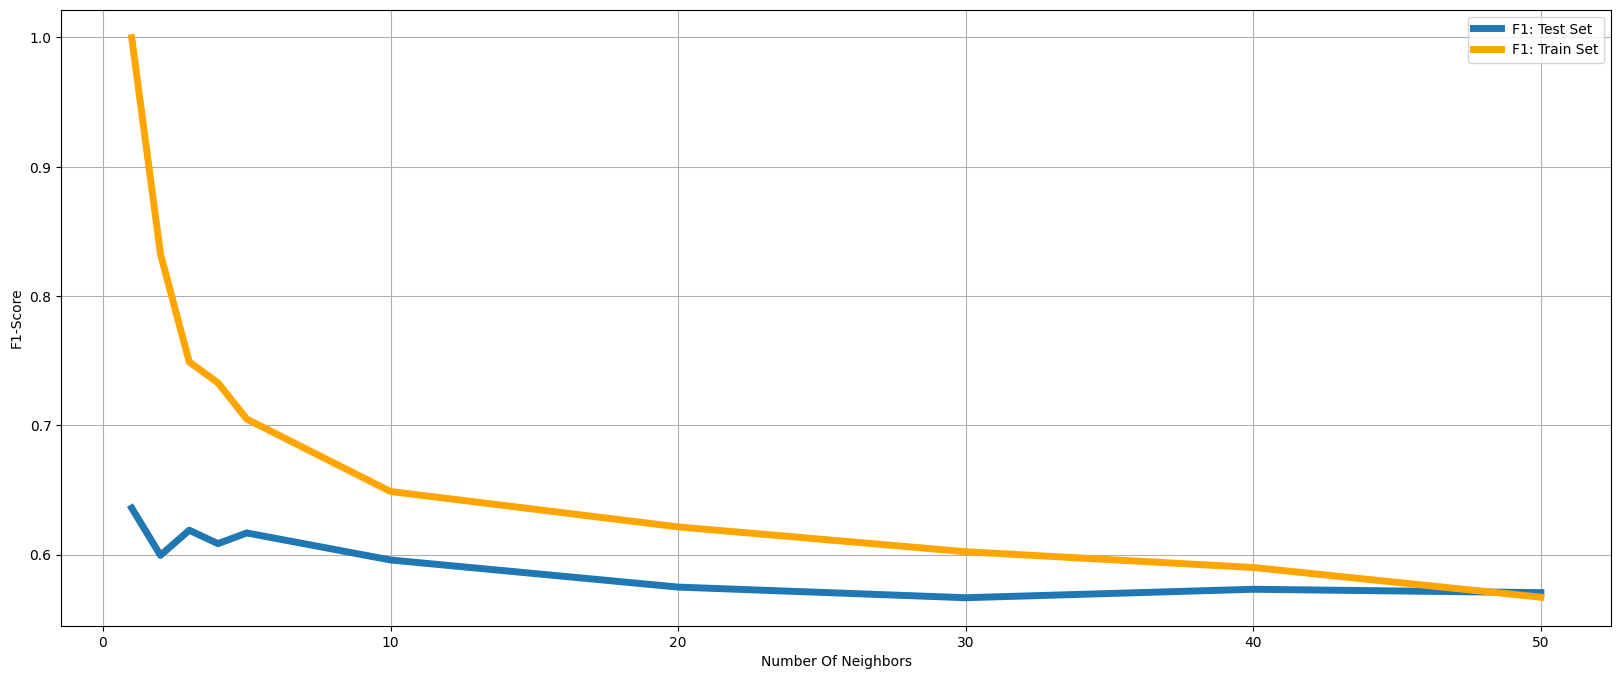

In [16]:
model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
model.fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)
predictions_train_proba = model.predict_proba(X_train)
predictions_test_proba = model.predict_proba(X_test)

multi_class_metrics('Trainning',y_train,predictions_train,class_names=numerizing_kernel.keys(),y_proba=predictions_train_proba)
multi_class_metrics('Testing',y_test,predictions_test,class_names=numerizing_kernel.keys(),y_proba=predictions_test_proba)

k_list = [1,2,3,4,5,10,20,30,40,50]
scores = []
scores_train = []
for k in k_list:
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model.fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    F1_train = f1_score(y_train, predictions_train, average='macro')
    scores_train.append(F1_train)
    predictions = model.predict(X_test)
    F1 = f1_score(y_test, predictions, average='macro')
    scores.append(F1)
plt.figure(figsize=(20,8))
plt.plot(k_list,scores,lw=5)
plt.plot(k_list,scores_train,lw=5,color='orange')
plt.xlabel('Number Of Neighbors')
plt.ylabel('F1-Score')
plt.legend(['F1: Test Set','F1: Train Set'])
plt.grid()
plt.show()

### Multi Class Decision Tree

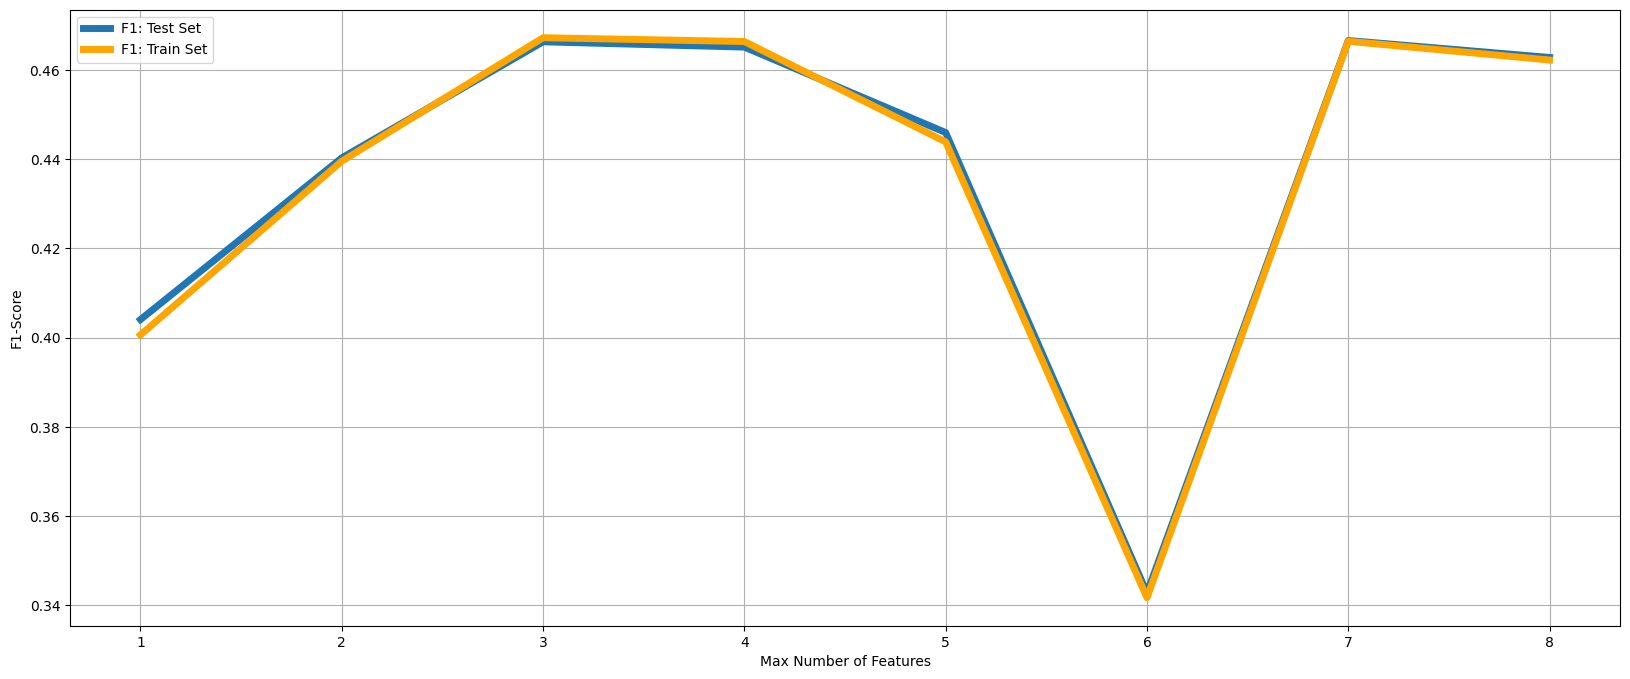

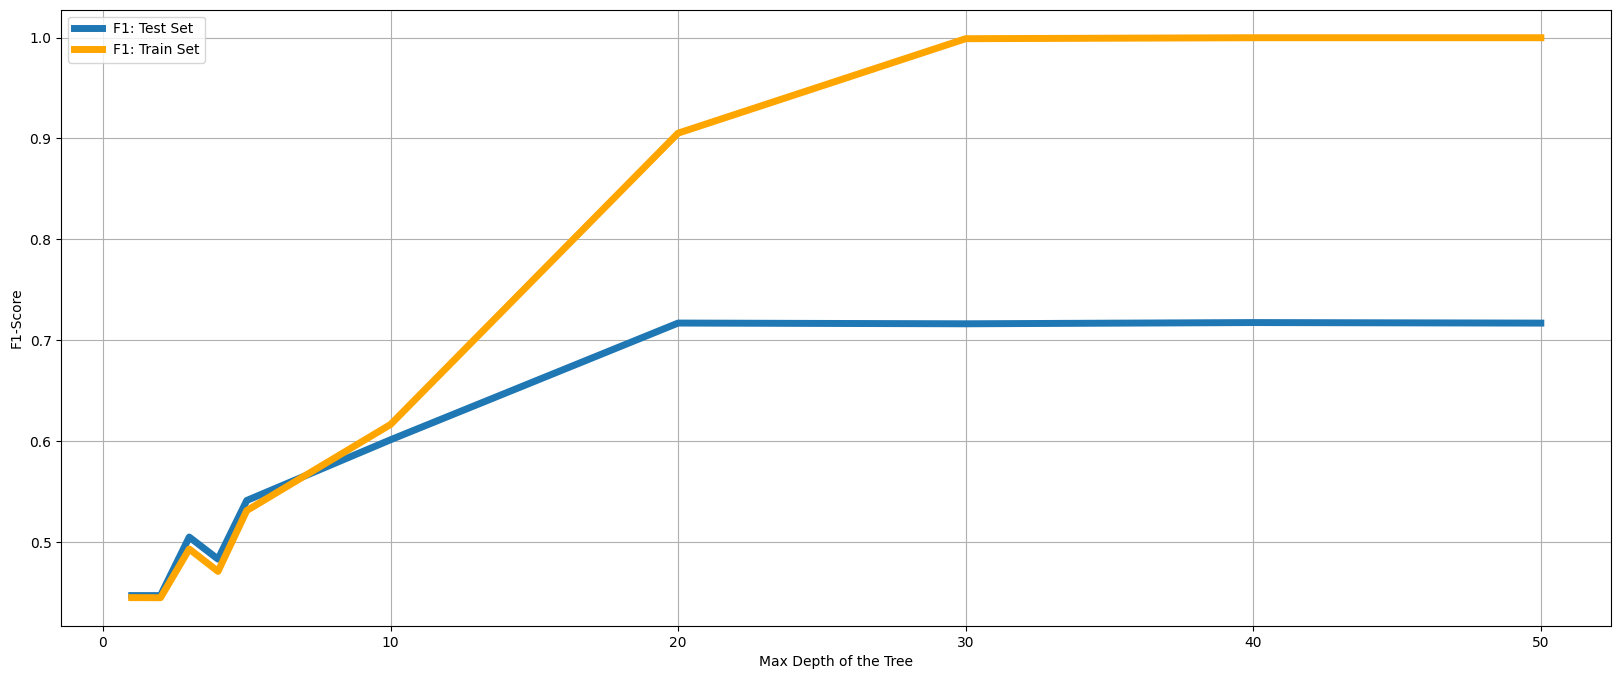

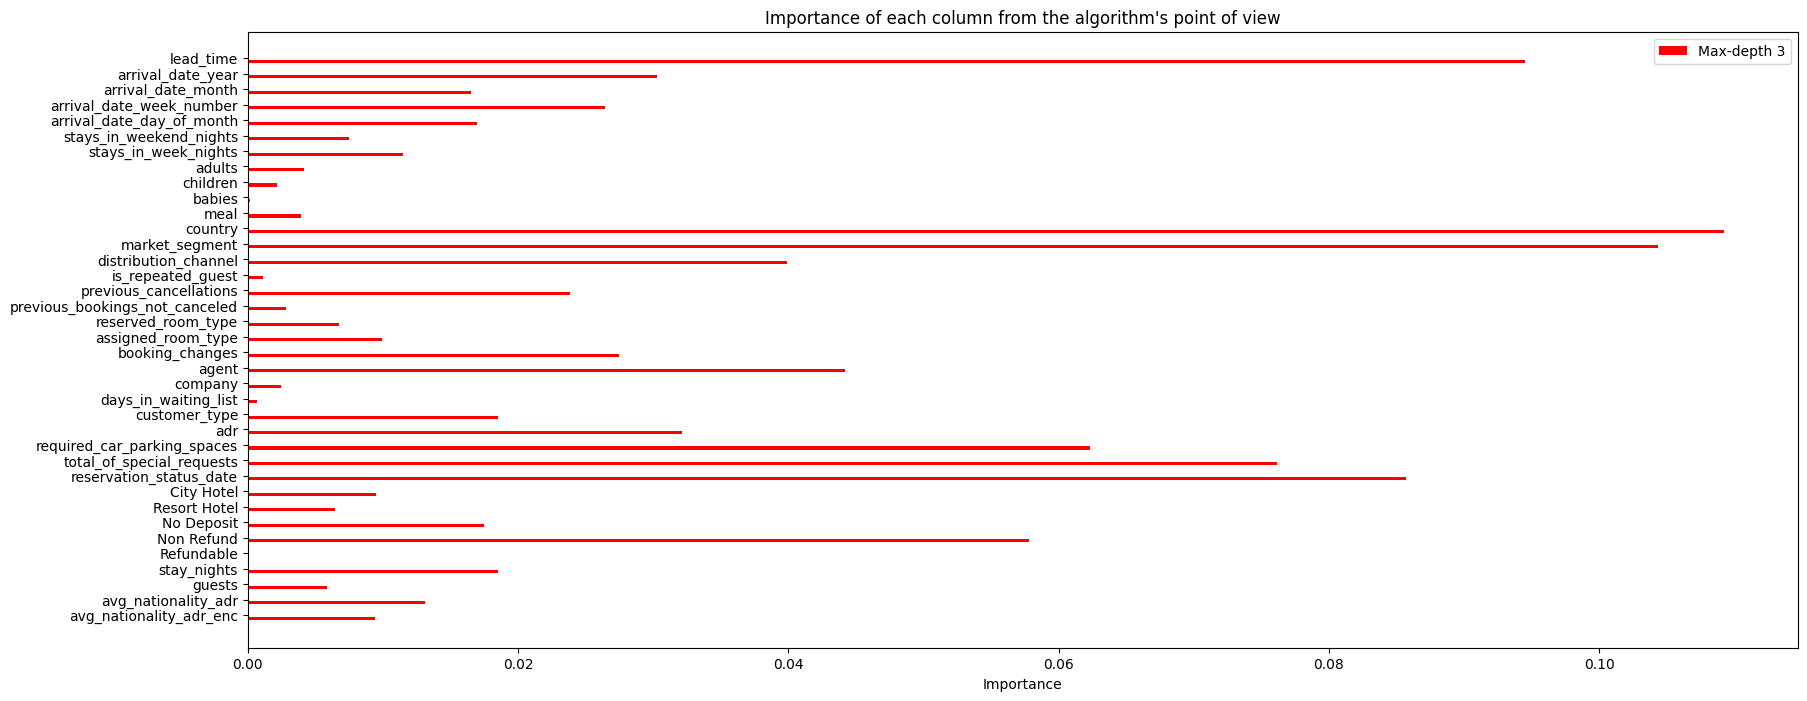

MULTI-CLASS CLASSIFICATION METRICS (Trainning)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.8830  0.8427    0.8624    30151
  No-Show     0.6246  0.2389    0.3456      808
Check-Out     0.9053  0.9378    0.9212    52269

AGGREGATED METRICS (Trainning)

Accuracy: 0.8965

Macro Average:
  Precision: 0.8043
  Recall:    0.6731
  F1-Score:  0.7097

Micro Average:
  Precision: 0.8965
  Recall:    0.8965
  F1-Score:  0.8965

Weighted Average:
  Precision: 0.8945
  Recall:    0.8965
  F1-Score:  0.8943

Overall Kappa: 0.7780

Log Loss: 0.2791

Confusion Matrix:
[[25407    49  4695]
 [  180   193   435]
 [ 3186    67 49016]]
MULTI-CLASS CLASSIFICATION METRICS (Testing)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.8259  0.7892    0.8071    12799
  No-Show     0.2321  0.0658    0.1026      395
Check-Out     0.8740  0.9071    0.8902    22476

AGGREGATED METRICS (Testing)

Accuracy: 0.8555

Macro Average:
  Precision: 0.6440
  Recall:    0.5874
  F1-Score:  0.

In [61]:
# Searching for optimum number of features
features_list = [1,2,3,4,5,6,7,8]
scores = []
scores_train = []
for no_features in features_list:
    model = DecisionTreeClassifier(max_features=no_features,max_depth=3)
    model.fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    F1_train = f1_score(y_train, predictions_train, average='macro')
    scores_train.append(F1_train)
    predictions = model.predict(X_test)
    F1 = f1_score(y_test, predictions, average='macro')
    scores.append(F1)
plt.figure(figsize=(20,8))
plt.plot(features_list,scores,lw=5)
plt.plot(features_list,scores_train,lw=5,color='orange')
plt.xlabel('Max Number of Features')
plt.ylabel('F1-Score')
plt.legend(['F1: Test Set','F1: Train Set'])
plt.grid()
plt.show()

# Searching for optimum maximum depth
depths_list = [1,2,3,4,5,10,20,30,40,50]
scores = []
scores_train = []
for depth in depths_list:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    F1_train = f1_score(y_train, predictions_train, average='macro')
    scores_train.append(F1_train)
    predictions = model.predict(X_test)
    F1 = f1_score(y_test, predictions, average='macro')
    scores.append(F1)
plt.figure(figsize=(20,8))
plt.plot(depths_list,scores,lw=5)
plt.plot(depths_list,scores_train,lw=5,color='orange')
plt.xlabel('Max Depth of the Tree')
plt.ylabel('F1-Score')
plt.legend(['F1: Test Set','F1: Train Set'])
plt.grid()
plt.show()

# Final model
model = DecisionTreeClassifier(criterion='entropy',max_features=6,max_depth=20,min_samples_leaf=5)
model.fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)
predictions_train_porba = model.predict_proba(X_train)
predictions_test_porba = model.predict_proba(X_test)

# Visualizing features importance's
labels = list(mcdf.columns)
features_importance = extract_feature_importance(model,labels,decision_model_name='dt')
fig, ax = plt.subplots(figsize=(20,8))
y_pos = np.arange(0,len(features_importance),1)
hbars = ax.barh(y_pos+0.2, features_importance, align='center',color='red',height=0.2)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title("Importance of each column from the algorithm's point of view")
plt.legend(['Max-depth 3','Max-depth 10'])
plt.show()

# Print Metrics
multi_class_metrics('Trainning',y_train,predictions_train,class_names=numerizing_kernel.keys(),y_proba=predictions_train_proba)
multi_class_metrics('Testing',y_test,predictions_test,class_names=numerizing_kernel.keys(),y_proba=predictions_test_proba)

### XGBoost

In [62]:
model = XGBClassifier(n_estimators=50,eval_metric='logloss',objective="multi:softmax")
model.fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)
predictions_train_proba = model.predict_proba(X_train)
predictions_test_proba = model.predict_proba(X_test)

multi_class_metrics('Trainning',y_train,predictions_train,class_names=numerizing_kernel.keys(),y_proba=predictions_train_proba)
multi_class_metrics('Testing',y_test,predictions_test,class_names=numerizing_kernel.keys(),y_proba=predictions_test_proba)

MULTI-CLASS CLASSIFICATION METRICS (Trainning)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9926  0.9268    0.9586    30151
  No-Show     0.9524  0.2475    0.3929      808
Check-Out     0.9496  0.9968    0.9727    52269

AGGREGATED METRICS (Trainning)

Accuracy: 0.9642

Macro Average:
  Precision: 0.9649
  Recall:    0.7237
  F1-Score:  0.7747

Micro Average:
  Precision: 0.9642
  Recall:    0.9642
  F1-Score:  0.9642

Weighted Average:
  Precision: 0.9652
  Recall:    0.9642
  F1-Score:  0.9619

Overall Kappa: 0.9227

Log Loss: 0.1301

Confusion Matrix:
[[27944     6  2201]
 [   46   200   562]
 [  162     4 52103]]
MULTI-CLASS CLASSIFICATION METRICS (Testing)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9889  0.8102    0.8907    12799
  No-Show     0.5714  0.0405    0.0757      395
Check-Out     0.8893  0.9953    0.9393    22476

AGGREGATED METRICS (Testing)

Accuracy: 0.9183

Macro Average:
  Precision: 0.8165
  Recall:    0.6153
  F1-Score:  0.

### LightGBM

In [63]:
model = lgbm.LGBMClassifier(learning_rate=0.09,max_depth=10)
model.fit(X_train,y_train,eval_metric=log_loss)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)
predictions_train_proba = model.predict_proba(X_train)
predictions_test_proba = model.predict_proba(X_test)

multi_class_metrics('Trainning',y_train,predictions_train,class_names=numerizing_kernel.keys(),y_proba=predictions_train_proba)
multi_class_metrics('Testing',y_test,predictions_test,class_names=numerizing_kernel.keys(),y_proba=predictions_test_proba)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2051
[LightGBM] [Info] Number of data points in the train set: 83228, number of used features: 37
[LightGBM] [Info] Start training from score -1.015366
[LightGBM] [Info] Start training from score -4.634777
[LightGBM] [Info] Start training from score -0.465180


/Users/parsajoneydi/.pyenv/versions/scientific/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/parsajoneydi/.pyenv/versions/scientific/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/parsajoneydi/.pyenv/versions/scientific/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/parsajoneydi/.pyenv/versions/scientific/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


MULTI-CLASS CLASSIFICATION METRICS (Trainning)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9903  0.9251    0.9566    30151
  No-Show     0.9567  0.3007    0.4576      808
Check-Out     0.9494  0.9955    0.9719    52269

AGGREGATED METRICS (Trainning)

Accuracy: 0.9633

Macro Average:
  Precision: 0.9655
  Recall:    0.7405
  F1-Score:  0.7954

Micro Average:
  Precision: 0.9633
  Recall:    0.9633
  F1-Score:  0.9633

Weighted Average:
  Precision: 0.9643
  Recall:    0.9633
  F1-Score:  0.9614

Overall Kappa: 0.9208

Log Loss: 0.1248

Confusion Matrix:
[[27893     7  2251]
 [   43   243   522]
 [  230     4 52035]]
MULTI-CLASS CLASSIFICATION METRICS (Testing)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9882  0.9169    0.9512    12799
  No-Show     0.7797  0.1165    0.2026      395
Check-Out     0.9419  0.9947    0.9676    22476

AGGREGATED METRICS (Testing)

Accuracy: 0.9571

Macro Average:
  Precision: 0.9033
  Recall:    0.6760
  F1-Score:  0.

### Adaboost

In [71]:
base_model = DecisionTreeClassifier(criterion='log_loss',
    max_depth=10,
    max_features=5,
    min_samples_split=10, 
    min_samples_leaf=5
)
model = AdaBoostClassifier(estimator=base_model,n_estimators=100,learning_rate=0.5,)
model.fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)
predictions_train_proba = model.predict_proba(X_train)
predictions_test_proba = model.predict_proba(X_test)

multi_class_metrics('Trainning',y_train,predictions_train,class_names=numerizing_kernel.keys(),y_proba=predictions_train_proba)
multi_class_metrics('Testing',y_test,predictions_test,class_names=numerizing_kernel.keys(),y_proba=predictions_test_proba)

MULTI-CLASS CLASSIFICATION METRICS (Trainning)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9637  0.9330    0.9481    30151
  No-Show     0.9867  0.6423    0.7781      808
Check-Out     0.9578  0.9806    0.9691    52269

AGGREGATED METRICS (Trainning)

Accuracy: 0.9601

Macro Average:
  Precision: 0.9694
  Recall:    0.8520
  F1-Score:  0.8984

Micro Average:
  Precision: 0.9601
  Recall:    0.9601
  F1-Score:  0.9601

Weighted Average:
  Precision: 0.9603
  Recall:    0.9601
  F1-Score:  0.9596

Overall Kappa: 0.9149

Log Loss: 0.9368

Confusion Matrix:
[[28130     3  2018]
 [   51   519   238]
 [ 1008     4 51257]]
MULTI-CLASS CLASSIFICATION METRICS (Testing)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9241  0.8727    0.8977    12799
  No-Show     0.8800  0.1671    0.2809      395
Check-Out     0.9200  0.9622    0.9407    22476

AGGREGATED METRICS (Testing)

Accuracy: 0.9213

Macro Average:
  Precision: 0.9080
  Recall:    0.6673
  F1-Score:  0.

### Cat Boost

In [85]:
# Basic CatBoost model (handles categorical features automatically
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    verbose=50
)

# Train
model.fit(X_train, y_train)

# Predict
predictions_train = model.predict(X_train).flatten()
predictions_test = model.predict(X_test).flatten()
predictions_train_proba = model.predict_proba(X_train)
predictions_test_proba = model.predict_proba(X_test)

multi_class_metrics('Training', y_train, predictions_train, 
                    class_names=numerizing_kernel.keys(), 
                    y_proba=predictions_train_proba)
multi_class_metrics('Testing', y_test, predictions_test, 
                    class_names=numerizing_kernel.keys(), 
                    y_proba=predictions_test_proba)

0:	learn: 0.7934349	total: 18ms	remaining: 1.78s
50:	learn: 0.8782261	total: 819ms	remaining: 787ms
99:	learn: 0.9094896	total: 1.66s	remaining: 0us
MULTI-CLASS CLASSIFICATION METRICS (Training)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9361  0.8278    0.8786    30151
  No-Show     0.8800  0.0272    0.0528      808
Check-Out     0.8970  0.9702    0.9322    52269

AGGREGATED METRICS (Training)

Accuracy: 0.9095

Macro Average:
  Precision: 0.9043
  Recall:    0.6084
  F1-Score:  0.6212

Micro Average:
  Precision: 0.9095
  Recall:    0.9095
  F1-Score:  0.9095

Weighted Average:
  Precision: 0.9110
  Recall:    0.9095
  F1-Score:  0.9042

Overall Kappa: 0.8021

Log Loss: 0.2659

Confusion Matrix:
[[24960     2  5189]
 [  150    22   636]
 [ 1555     1 50713]]
MULTI-CLASS CLASSIFICATION METRICS (Testing)
    Class  Precision  Recall  F1-Score  Support
 Canceled     0.9288  0.8224    0.8724    12799
  No-Show     0.6667  0.0101    0.0200      395
Check-Out     0.8939

#### Instead of giving weight to classes to compensate for the lack of no-show data rows, we could have resampled the data; which was done but resulted in lots of overfitting and messy confusion matrices so much so that in the end it is preferable to stay with weighted classes.

### Comparison (Binary Class vs Multi Class)
#### We use LightGBM as the repsentative of Multi-Class classification and Random Forest as the represntative of binray classification methods for comparison of the two methods on this problem.

Training set size: 83228
Test set size: 35670
Classes: ['Canceled' 'Check-Out' 'No-Show']
Class distribution:
1    52321
0    30065
2      842
Name: count, dtype: int64

RANDOM FOREST - BINARY CLASSIFIERS WITH VOTING

Training binary classifier for: Canceled
  Positive samples (Canceled): 30065
  Negative samples (others): 53163
  Ratio: 0.566

Training binary classifier for: Check-Out
  Positive samples (Check-Out): 52321
  Negative samples (others): 30907
  Ratio: 1.693

Training binary classifier for: No-Show
  Positive samples (No-Show): 842
  Negative samples (others): 82386
  Ratio: 0.010

Evaluating PROBABILITY method

Performance with PROBABILITY method:
  Train Accuracy: 0.9538
  Test Accuracy:  0.9186
  Overfitting Gap: 0.0353
  Train F1 (macro): 0.9072
  Test F1 (macro):  0.7320

Evaluating VOTING method

Performance with VOTING method:
  Train Accuracy: 0.9538
  Test Accuracy:  0.9186
  Overfitting Gap: 0.0353
  Train F1 (macro): 0.9072
  Test F1 (macro):  0.7320

Best bina

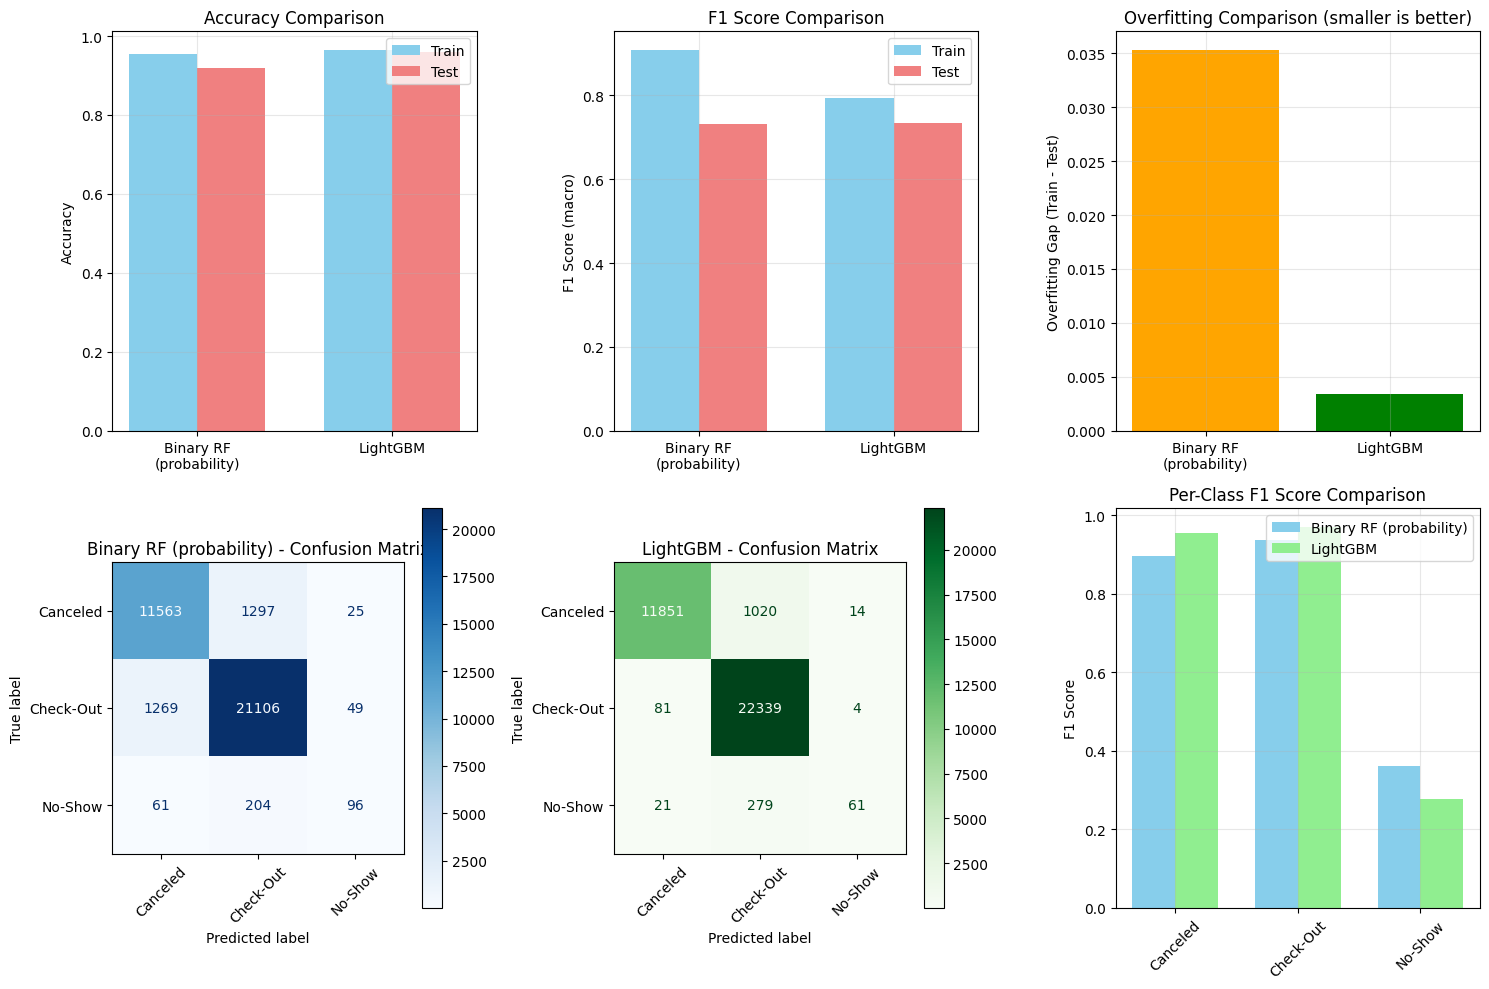


COMPARISON TABLE
           Metric  RF Train  RF Test  LGB Train  LGB Test
         Accuracy  0.953814 0.918559   0.963642  0.960219
       F1 (macro)  0.907174 0.732034   0.794575  0.733830
Precision (macro)  0.909258 0.798385   0.952921  0.902888
   Recall (macro)  0.905192 0.701517   0.740988  0.694979

FEATURE IMPORTANCE - BINARY RANDOM FOREST


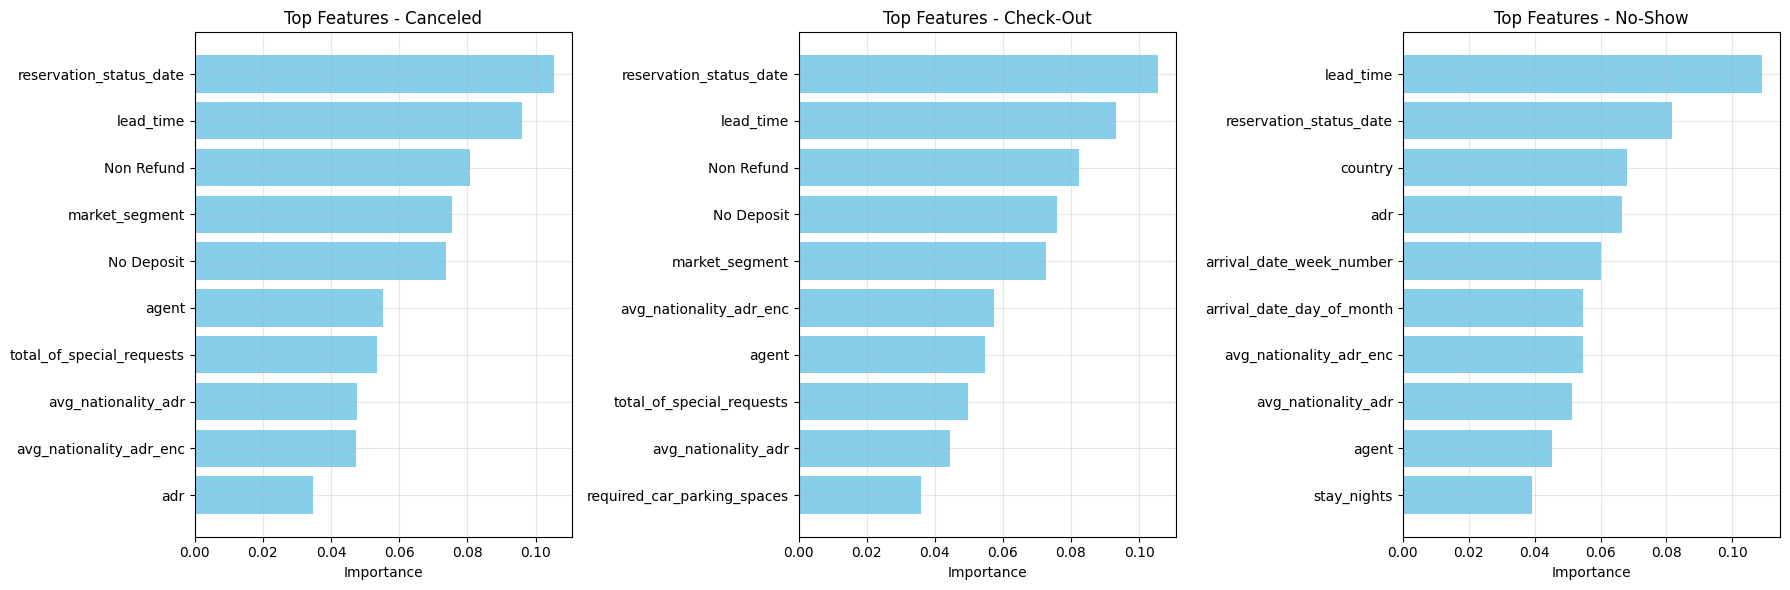

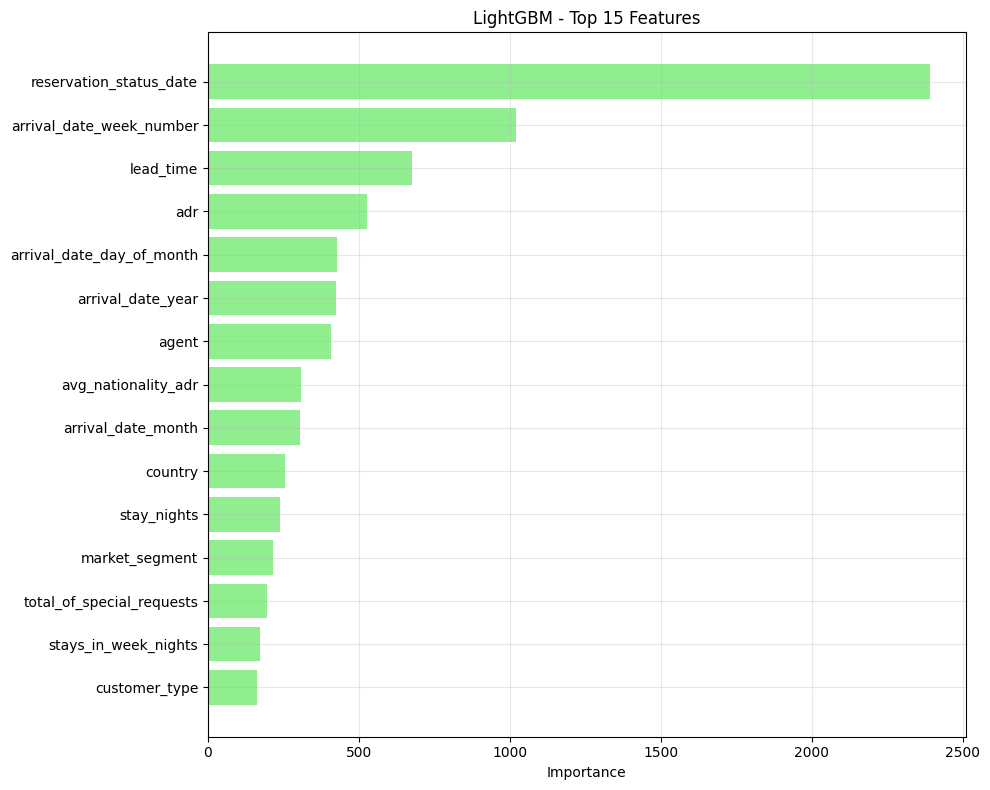


FINAL VERDICT
LightGBM performs better on test data
   Improvement: 0.18% higher F1 score


In [23]:
# Preperring data
df = odf.copy(True)

# Create target variable with 3 classes
def create_multiclass_target(row):
    if row['Canceled'] == 1:
        return 'Canceled'
    elif row['No-Show'] == 1:
        return 'No-Show'
    else:
        return 'Check-Out'

df['Reservation_Status'] = df.apply(create_multiclass_target, axis=1)

# Remove original binary columns
df = df.drop(['Canceled', 'No-Show', 'Check-Out'], axis=1)

# Encode target
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Reservation_Status'])
class_names = label_encoder.classes_  # ['Canceled', 'Check-Out', 'No-Show']

# Remove target from features
X = df.drop('Reservation_Status', axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Classes: {class_names}")
print(f"Class distribution:\n{pd.Series(y_train).value_counts()}")

print("\n" + "="*60)
print("RANDOM FOREST - BINARY CLASSIFIERS WITH VOTING")
print("="*60)

class BinaryRandomForestWithVoting:
    def __init__(self, n_estimators=100, max_depth=20, min_samples_split=10, 
                 min_samples_leaf=4, random_state=42):
        """
        Initialize binary classifiers for each class
        """
        self.class_names = None
        self.classifiers = {}
        self.params = {
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'min_samples_split': min_samples_split,
            'min_samples_leaf': min_samples_leaf,
            'criterion': 'gini',
            'random_state': random_state,
            'n_jobs': -1
        }
    
    def fit(self, X, y, class_names):
        """
        Train one binary Random Forest per class
        """
        self.class_names = class_names
        
        for class_name in class_names:
            print(f"\nTraining binary classifier for: {class_name}")
            
            # Create binary labels (1 for current class, 0 for others)
            y_binary = (y == class_name).astype(int)
            
            # Count samples
            positive_count = y_binary.sum()
            negative_count = len(y_binary) - positive_count
            print(f"  Positive samples ({class_name}): {positive_count}")
            print(f"  Negative samples (others): {negative_count}")
            print(f"  Ratio: {positive_count/negative_count:.3f}")
            
            # Handle class imbalance with class_weight
            clf = RandomForestClassifier(
                **self.params,
                class_weight='balanced'  # Important for imbalanced data
            )
            clf.fit(X, y_binary)
            self.classifiers[class_name] = clf
        
        return self
    
    def predict_proba(self, X):
        """
        Get probability for each class
        """
        proba_matrix = np.zeros((X.shape[0], len(self.class_names)))
        
        for i, class_name in enumerate(self.class_names):
            # Get probability of belonging to this class
            proba = self.classifiers[class_name].predict_proba(X)[:, 1]
            proba_matrix[:, i] = proba
        
        # Normalize probabilities to sum to 1
        proba_matrix = proba_matrix / proba_matrix.sum(axis=1, keepdims=True)
        
        return proba_matrix
    
    def predict(self, X, method='probability'):
        """
        Predict class using voting or probability method
        
        Parameters:
        - method: 'probability' (highest proba) or 'voting' (majority vote)
        """
        if method == 'probability':
            # Method 1: Choose class with highest probability
            proba_matrix = self.predict_proba(X)
            predictions = np.argmax(proba_matrix, axis=1)
            return np.array([self.class_names[i] for i in predictions])
        
        elif method == 'voting':
            # Method 2: Binary decisions with majority vote
            votes = np.zeros((X.shape[0], len(self.class_names)))
            
            for i, class_name in enumerate(self.class_names):
                # Get binary prediction (0 or 1)
                pred_binary = self.classifiers[class_name].predict(X)
                votes[:, i] = pred_binary
            
            # Handle ties and no votes
            row_sums = votes.sum(axis=1)
            multiple_predictions = row_sums > 1
            no_predictions = row_sums == 0
            
            # For rows with multiple votes, use probability method
            if multiple_predictions.any():
                proba_matrix = self.predict_proba(X)
                for idx in np.where(multiple_predictions)[0]:
                    # Get classes that voted positive
                    voting_classes = np.where(votes[idx] == 1)[0]
                    # Choose highest probability among voting classes
                    best_class = voting_classes[np.argmax(proba_matrix[idx, voting_classes])]
                    votes[idx] = 0
                    votes[idx, best_class] = 1
            
            # For rows with no votes, use highest probability
            if no_predictions.any():
                proba_matrix = self.predict_proba(X)
                for idx in np.where(no_predictions)[0]:
                    best_class = np.argmax(proba_matrix[idx])
                    votes[idx] = 0
                    votes[idx, best_class] = 1
            
            predictions = np.argmax(votes, axis=1)
            return np.array([self.class_names[i] for i in predictions])
    
    def predict_with_confidence(self, X):
        """
        Predict class with confidence score
        """
        proba_matrix = self.predict_proba(X)
        predictions = np.argmax(proba_matrix, axis=1)
        confidence = np.max(proba_matrix, axis=1)
        
        return {
            'predictions': np.array([self.class_names[i] for i in predictions]),
            'confidence': confidence,
            'probabilities': proba_matrix
        }

# Convert y_train and y_test to class names for binary classifiers
y_train_names = label_encoder.inverse_transform(y_train)
y_test_names = label_encoder.inverse_transform(y_test)

# Initialize and train binary Random Forest with voting
binary_rf = BinaryRandomForestWithVoting(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

binary_rf.fit(X_train_scaled, y_train_names, class_names)

# Try both methods and pick the best
methods_to_try = ['probability', 'voting']
best_rf_binary = None
best_rf_binary_score = 0
best_method_name = ''

for method in methods_to_try:
    print(f"\n{'='*60}")
    print(f"Evaluating {method.upper()} method")
    print(f"{'='*60}")
    
    # Predict using current method
    rf_train_pred_names = binary_rf.predict(X_train_scaled, method=method)
    rf_test_pred_names = binary_rf.predict(X_test_scaled, method=method)
    
    # Convert back to encoded labels
    rf_train_pred = label_encoder.transform(rf_train_pred_names)
    rf_test_pred = label_encoder.transform(rf_test_pred_names)
    
    # Get probabilities
    rf_test_proba = binary_rf.predict_proba(X_test_scaled)
    
    # Calculate metrics
    rf_train_acc = accuracy_score(y_train_names, rf_train_pred_names)
    rf_test_acc = accuracy_score(y_test_names, rf_test_pred_names)
    rf_train_f1 = f1_score(y_train_names, rf_train_pred_names, average='macro', labels=class_names)
    rf_test_f1 = f1_score(y_test_names, rf_test_pred_names, average='macro', labels=class_names)
    
    print(f"\nPerformance with {method.upper()} method:")
    print(f"  Train Accuracy: {rf_train_acc:.4f}")
    print(f"  Test Accuracy:  {rf_test_acc:.4f}")
    print(f"  Overfitting Gap: {rf_train_acc - rf_test_acc:.4f}")
    print(f"  Train F1 (macro): {rf_train_f1:.4f}")
    print(f"  Test F1 (macro):  {rf_test_f1:.4f}")
    
    # Store best method
    if rf_test_f1 > best_rf_binary_score:
        best_rf_binary_score = rf_test_f1
        best_rf_binary = {
            'method': method,
            'train_pred': rf_train_pred,
            'test_pred': rf_test_pred,
            'train_proba': binary_rf.predict_proba(X_train_scaled),
            'test_proba': rf_test_proba,
            'train_acc': rf_train_acc,
            'test_acc': rf_test_acc,
            'train_f1': rf_train_f1,
            'test_f1': rf_test_f1
        }
        best_method_name = method

print(f"\nBest binary RF method: {best_method_name.upper()}")
print(f"   Test F1 Score: {best_rf_binary['test_f1']:.4f}")

# Use the best method for final predictions
rf_train_pred = best_rf_binary['train_pred']
rf_test_pred = best_rf_binary['test_pred']
rf_train_proba = best_rf_binary['train_proba']
rf_test_proba = best_rf_binary['test_proba']
rf_train_acc = best_rf_binary['train_acc']
rf_test_acc = best_rf_binary['test_acc']
rf_train_f1 = best_rf_binary['train_f1']
rf_test_f1 = best_rf_binary['test_f1']

# LightGBM
print("\n" + "="*60)
print("LIGHTGBM - MULTICLASS")
print("="*60)

# LightGBM for multiclass
best_lgb = lgbm.LGBMClassifier(
    objective='multiclass',  # KEY: multiclass objective
    num_class=3,  # Number of classes
    learning_rate=0.09,
    max_depth=10,
    n_estimators=100,
    num_leaves=31,  # Key LightGBM parameter
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=0.1,  # L2 regularization
    random_state=42,
    n_jobs=-1
)

# Train with early stopping
best_lgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    eval_metric='multi_logloss',
    callbacks=[lgbm.early_stopping(stopping_rounds=50, verbose=True)]
)

# Predictions
lgb_train_pred = best_lgb.predict(X_train_scaled)
lgb_test_pred = best_lgb.predict(X_test_scaled)
lgb_train_proba = best_lgb.predict_proba(X_train_scaled)
lgb_test_proba = best_lgb.predict_proba(X_test_scaled)

# Metrics for LGB
lgb_train_acc = accuracy_score(y_train, lgb_train_pred)
lgb_test_acc = accuracy_score(y_test, lgb_test_pred)
lgb_train_f1 = f1_score(y_train, lgb_train_pred, average='macro')
lgb_test_f1 = f1_score(y_test, lgb_test_pred, average='macro')

print(f"\nLightGBM Performance:")
print(f"  Train Accuracy: {lgb_train_acc:.4f}")
print(f"  Test Accuracy:  {lgb_test_acc:.4f}")
print(f"  Overfitting Gap: {lgb_train_acc - lgb_test_acc:.4f}")
print(f"  Train F1 (macro): {lgb_train_f1:.4f}")
print(f"  Test F1 (macro):  {lgb_test_f1:.4f}")
print(f"  Best iterations: {best_lgb.best_iteration_}")

# Comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Accuracy Comparison
ax1 = axes[0, 0]
models = ['Binary RF\n({})'.format(best_method_name), 'LightGBM']
train_acc = [rf_train_acc, lgb_train_acc]
test_acc = [rf_test_acc, lgb_test_acc]
x = np.arange(len(models))
width = 0.35
ax1.bar(x - width/2, train_acc, width, label='Train', color='skyblue')
ax1.bar(x + width/2, test_acc, width, label='Test', color='lightcoral')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(True, alpha=0.3)

# F1 Score Comparison
ax2 = axes[0, 1]
train_f1 = [rf_train_f1, lgb_train_f1]
test_f1 = [rf_test_f1, lgb_test_f1]
ax2.bar(x - width/2, train_f1, width, label='Train', color='skyblue')
ax2.bar(x + width/2, test_f1, width, label='Test', color='lightcoral')
ax2.set_ylabel('F1 Score (macro)')
ax2.set_title('F1 Score Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Overfitting Gap
ax3 = axes[0, 2]
overfit_gap_rf = rf_train_acc - rf_test_acc
overfit_gap_lgb = lgb_train_acc - lgb_test_acc
ax3.bar(models, [overfit_gap_rf, overfit_gap_lgb], color=['orange', 'green'])
ax3.set_ylabel('Overfitting Gap (Train - Test)')
ax3.set_title('Overfitting Comparison (smaller is better)')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3)

# Confusion Matrices - Binary Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, rf_test_pred, 
                                       display_labels=class_names,
                                       ax=axes[1, 0], cmap='Blues')
axes[1, 0].set_title(f'Binary RF ({best_method_name}) - Confusion Matrix')
axes[1, 0].set_xticklabels(class_names, rotation=45)

# Confusion Matrices - LightGBM
ConfusionMatrixDisplay.from_predictions(y_test, lgb_test_pred,
                                       display_labels=class_names,
                                       ax=axes[1, 1], cmap='Greens')
axes[1, 1].set_title('LightGBM - Confusion Matrix')
axes[1, 1].set_xticklabels(class_names, rotation=45)

# Per-class F1 Score comparison
ax6 = axes[1, 2]
rf_per_class_f1 = f1_score(y_test, rf_test_pred, average=None)
lgb_per_class_f1 = f1_score(y_test, lgb_test_pred, average=None)
x = np.arange(len(class_names))
width = 0.35
ax6.bar(x - width/2, rf_per_class_f1, width, label=f'Binary RF ({best_method_name})', color='skyblue')
ax6.bar(x + width/2, lgb_per_class_f1, width, label='LightGBM', color='lightgreen')
ax6.set_ylabel('F1 Score')
ax6.set_title('Per-Class F1 Score Comparison')
ax6.set_xticks(x)
ax6.set_xticklabels(class_names, rotation=45)
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Metrics table
print("\n" + "="*80)
print("COMPARISON TABLE")
print("="*80)

comparison_data = {
    'Metric': ['Accuracy', 'F1 (macro)', 'Precision (macro)', 'Recall (macro)'],
    'RF Train': [
        accuracy_score(y_train, rf_train_pred),
        f1_score(y_train, rf_train_pred, average='macro'),
        precision_score(y_train, rf_train_pred, average='macro'),
        recall_score(y_train, rf_train_pred, average='macro')
    ],
    'RF Test': [
        accuracy_score(y_test, rf_test_pred),
        f1_score(y_test, rf_test_pred, average='macro'),
        precision_score(y_test, rf_test_pred, average='macro'),
        recall_score(y_test, rf_test_pred, average='macro')
    ],
    'LGB Train': [
        accuracy_score(y_train, lgb_train_pred),
        f1_score(y_train, lgb_train_pred, average='macro'),
        precision_score(y_train, lgb_train_pred, average='macro'),
        recall_score(y_train, lgb_train_pred, average='macro')
    ],
    'LGB Test': [
        accuracy_score(y_test, lgb_test_pred),
        f1_score(y_test, lgb_test_pred, average='macro'),
        precision_score(y_test, lgb_test_pred, average='macro'),
        recall_score(y_test, lgb_test_pred, average='macro')
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Classification reports
print("\n" + "="*80)
print("FEATURE IMPORTANCE - BINARY RANDOM FOREST")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, class_name in enumerate(class_names):
    # Get feature importance for this class's binary classifier
    importance = binary_rf.classifiers[class_name].feature_importances_
    
    # Get top 10 features
    feature_importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': importance
    }).sort_values('importance', ascending=True).tail(10)
    
    ax = axes[idx]
    ax.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='skyblue')
    ax.set_xlabel('Importance')
    ax.set_title(f'Top Features - {class_name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# LightGBM Feature Importance
fig, ax = plt.subplots(figsize=(10, 8))
lgb_importance = best_lgb.feature_importances_
lgb_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb_importance
}).sort_values('importance', ascending=True).tail(15)

ax.barh(lgb_importance_df['feature'], lgb_importance_df['importance'], color='lightgreen')
ax.set_xlabel('Importance')
ax.set_title('LightGBM - Top 15 Features')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final verdict
print("\n" + "="*80)
print("FINAL VERDICT")
print("="*80)

if lgb_test_f1 > rf_test_f1:
    print("LightGBM performs better on test data")
    print(f"   Improvement: {(lgb_test_f1 - rf_test_f1)*100:.2f}% higher F1 score")
elif rf_test_f1 > lgb_test_f1:
    print("Random Forest performs better on test data")
    print(f"{(rf_test_f1 - lgb_test_f1)*100:.2f}% higher F1 score")
else:
    print("Both models perform similarly")

<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">What Is The Best Model</b>: The best model according to overall metrics and especially log_loss is lightGBM model. Though all models perform on identifying no-show records poorly.</p>

<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">What Is The Best Metric</b>: Arguably the most suitable metric is <b style="text-decoration: underline;">macro f1-score</b> since other metrics are biased by class imbalance and often favor the majority class.</p>

<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">KNN For Multi Label Classification</b>: One option is to train a separate knn model for each label independently. Another option is to allocate weight to neighbors based on their and distance and apply voting to all neighbors to choose the most likely label.</p>

<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">Decision Tree For Multi Label Classification</b>: A simple approach would be to just extend the decision tree to decide on the label as well which is known as <b style="text-decoration: underline;">multi-label decision tree (ML-DT)</b>. Another option would be to transform each combination of labels into a class and then apply a traditional decision tree on it which is commonly known as <b style="text-decoration: underline;">lable powerset (LP)</b>.</p>

<p style="font-size: 1.8rem"><b style="font-size: 2.1rem">Footbal Players Classification</b>: A suitable metric we can use is <b style='text-decoration: underline;'>Exact Match Ration</b>. Because it shows the amount of samples whose labels labels have been predicted correctly and also all of the labels which it belongs to have been predicted. It is obvious that this metric is very strict and kind of acts as the lower bound of accuracy so it doesn't capture entire picture. We could use another metric in complement with this metric and that is <b style='text-decoration: underline;'>Hamming</b> metric. Hamming calculate the ratio of correct label perdictions to all label predictions, which is helpful in identifying labels that our model is weak to predict.</p>

## Challenging Questions

<ol style='font-size: 1.8rem;paddin-left: .8rem;'>
    <li style="margin-bottom: 1.5rem;">
        <b>Bias-Varince Trade Off</b>: High bias (low variance) allows the model to be percise and focused but it increases the risk of focusing on the wrong pattern and biasing on the wrong bias point. High variance (low bias) allows the be more flexible and capture a wider range of patterns which might help shift the average towards the right target. But decreases percision which means individual predictions contain larger errors.
    </li>
    <li style="margin-bottom: 1.5rem;">
        <b>When does Kernel Regression outperform Linear Regression (Kernel Trick)</b>: In cases the relation among our data is mostly non-linear, we can not just simply apply a linear model on it. We could use a kernel to map our data to higher dimension where linear patterns emerge and then we can use the linear model on the newly generated data.
    </li>
    <li style="margin-bottom: 1.5rem;">
        <b>Compare L1 vs L2 regularization</b>: L1 regularization penalizes the absolute value of the coefficients while L2 does the same for their squared value. This means that L1 could shirnk some values to zero unlike L2. Lasso uses L1 regularization while Ridge regression uses L2 regularization. This is the main reason why Lasso is a sparse model, it might perform feature selection and neglect some features entirely, while Ridge model keeps all model eventhough their influence might be little. It is quite obvious that when We have many irrelevant features Lasso models outperforms Ridge regression. On theo ther hand, when the features are highly correlated and influential on our target Ridge regression performs better in capturing the pattern.
    </li>
    <li style="margin-bottom: 1.5rem;">
        <b>Explain why MAPE is unreliable in some datasets</b>: When the absolute values are close to zero, MAPE metric grows unboundedly very easily, let alone exact zero samples. This means MAPE might be indicating a very large error while the difference is actually not that much.
    </li>
    <li style="margin-bottom: 1.5rem;">
        <b>Discuss the effect of outliers on regression models</b>: The best answer is that it depends heavily on the model. For example sensitive models like linear least square methods a data point with very high y or x biasas the model significantly. But a more robust model like a decision tree, absorbs these outliers easily by their set regularizations. For example a data point might have very large coefficient in a dimension but because the maximum depth of the tree is reached no more leaves could be created. Or it could be limited by the minimum samples per leaf paramter. For example let's say we have 5 data points with very large values in a certain dimension but because the minmum number of samples required to create a new leaf is set to 10, no leaves are created.
    </li>
    <li style="margin-bottom: 1.5rem;">
        <b>Explain the effect of class imbalance on binary metrics</b>: The problem boils down to what kind of mistake is the model making. For example Accuracy shows both true positive and true negative predictions, but does not capture the weight of each type. This means that a model that is trained weakly, because of class imbalance, and is very good at identifying positives and very bad at identifying negatives, could still get a very high accuracy if the test consists mostly of positives, which is misleading.
    </li>
    <li style="margin-bottom: 1.5rem;">
        <b>Explain how the decision boundaries of your models differ fundamentally </b>: Each model draws bounderies differentlly and based on its own mechanism. Som draw them linearly which expand in both axis into infinity (Linear), some draw them based on a polynomial or logarithmic pattern (Kernel Trick), some draw them in a way that bounderies close on themseveles and results in the creation of separated areas (Decision Tree) and there are models that could capture general non-linear bounderies (patterns) such as deep neural networks.
    </li>
    <li style="margin-bottom: 1.5rem;">
        <b>Explain effect of K in KNN</b>: The paramter K specifies the effective radius of decision making. For example it shows how many neighbors are taken into account when specifying the class of a sample point in multi class classification.
    </li>
    <li style="margin-bottom: 1.5rem;">
        <b> Overfitting in Decision Trees</b>: The number of leaves in decision tree grows exponentially, which means leaves can reach very specific feature conditions very easily. This is the reason why decision trees overfit easily. We can however compensate this flaw with max depth, which limits ovefitting but it's not enough. Leaves can reach overfittness earlier than hitting the depth limit. Another reason why max depth is not enough, is that it does not control the spliting of child node, which might be very uneven and result in very low sample leaves. A popular choice to fight overfitting is prunning which removes the overfitted branches. This can be done during the learning process and prevent overfitted branches from emerging (pre-prun) or after training is done (post-prun). The conditons to whether keep or prun the some leaves or branches could be different things such as min number of samples, max depth, max number of leaves ... .
    </li>
    <li style="margin-bottom: 1.5rem;">
        <b>Explain why Tree-based models are good feature selectors</b>: Decision trees trie to maximize information gain at each node. In other words when data from a single node, is splitted into two, it is done in way that continuing in each node, provides us with new information as much as possible. This means that the two child nodes should be oppsites ideally, or orthogonal as much as possible. This info gain maximization, is what forces the model to use the informing features more and favor them over useless ones.
    </li>
    <li style="margin-bottom: 1.5rem;">
        <b>Micro vs Macro vs Weighted F1</b>: When all classes are euqally important macro f1 outperforms other metrics, because it can show that our model is weak at identifying some classes as opposing to micro f1 which might show high accuracy just because the model performed better on the majority class. When it is the minority class that is actually our intereset (i.e. fraud detection) weighted f1 can miscompare two models. Consider model A that detects legitemacy really well but is weak at identifying frauds and (high TP and low TN) and model B that is the exact opposite (low TP and high TN). In this case weighted f1 favors class A which is not the suitable model for our need. Micro f1 conders the entire predictions (TP, FN and FP accross all classes) but fails to show how these are ditributed among different classes. A large class might be identified perfectly but several other small classes, terribly, and the micro f1 will show a high score.
</ol>